# Analysis of mutation and GCE enrichment in positive epitopes (versus negative peptides)

# Import Statements (libraries + Functions)

In [964]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

%matplotlib inline

In [965]:
#import sklearn

In [966]:
import scipy.stats
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import spearmanr
from scipy.stats import ranksums

In [967]:
#from Bio import SeqIO

In [968]:
#import io

In [969]:
import json

In [970]:
# import screed
# import mmh3

In [971]:
#import subprocess

In [972]:
#from pycirclize import Circos

In [973]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch
import matplotlib.ticker as mticker


In [974]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [975]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [976]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

#### Define sets of coord cols for using BioFrame

In [977]:
Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
HmReg_CoordCols = ("Chr", "Start", "End")
HmRegion_CoordCols = HmReg_CoordCols
Epitope_CoordCols = ("Chrom", "Rv_Start", "Rv_End")
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")


#### Pandas Viewing Settings

In [978]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Parse `Mtb151CI` Isolate Metadata

In [17]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [18]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [19]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  
ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


# Import/parse processed H37rv genome annotations

In [20]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [21]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded


### Parse the WHO AR Variant Catalog (Mtb)

In [22]:
WHO_ResVar_DF = pd.read_csv("../../References/WHO_MtbAMR_Catalog/WHO_resistance_variants_all.csv", sep =",")
WHO_ResVar_LVL1_DF = WHO_ResVar_DF[ WHO_ResVar_DF["confidence"] == '1) Assoc w R']
WHO_ResVar_DF.shape

(17419, 5)

In [23]:
WHO_ResVar_LVL1_DF.shape

(201, 5)

In [24]:
WHO_ConfResGenes = list(WHO_ResVar_LVL1_DF["gene"].unique())
print(len(WHO_ConfResGenes))
print( WHO_ConfResGenes )

15
['inhA', 'rrs', 'eis', 'tlyA', 'embB', 'embA', 'ethA', 'katG', 'gyrA', 'rplC', 'gyrB', 'pncA', 'rpoB', 'rpsL', 'gid']


# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [25]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"


### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [26]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                    sep="\t")
#HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"] = HmMapRegs_ParaRegs_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 13)

In [27]:
Rv_HHR_DF = HmMapRegs_ParaRegs_k19w19_DF
Rv_HHR_DF.shape

(200, 13)

In [28]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                        sep="\t")

#HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"] = HmMapRegs_LocalRepeats_k19w19_DF["Overlap_Genes"].fillna("_")

HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [29]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 13)

In [30]:
HmMapRegs_ParaRegs_k19w19_DF.head(2)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001


#### Peak at head of each HmMap Regions DFs

In [31]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004


In [32]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [33]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 24)

In [34]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 34)

In [35]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 34)

In [36]:
HmMap_Aln_PR_ExactCopy_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID == 1.0")
print(HmMap_Aln_PR_ExactCopy_DF.shape)

(255, 34)


In [37]:
HmMap_Aln_PR_NoPerfAln_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID != 1.0")
print(HmMap_Aln_PR_NoPerfAln_DF.shape)

(385, 34)


In [38]:

HmMap_Aln_PR_MaxSeqID99_DF = HmMap_Aln_k19w19_NoOverlap_DF.query("SeqID <= 0.99")
print(HmMap_Aln_PR_MaxSeqID99_DF.shape)

(331, 34)


### Parse in HomologyMap Alignment Variants DFs

In [39]:
Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

In [40]:
# Build trimmed + unique HM SNPs DF
UnqSNPs_TarCol = ['Query_Name', 'Query_Start', 'Query_End', 'Ref', 'Alt', 'SNP']

HM_Var_SNPs_TrimUnq_DF = Mtb_HM_Var_SNPs_DF[UnqSNPs_TarCol].drop_duplicates()
HM_Var_SNPs_TrimUnq_DF.shape

(51590, 6)

In [41]:
Mtb_HM_Var_DF.shape

(79508, 13)

In [42]:
Mtb_HM_Var_SNPs_DF.shape

(65617, 13)

# Parse curated TB antigens + epitopes (T-cell, CD4+)
Source Datasets: (Panda-24, Lindestam-16)

In [1118]:
Repo_Epitope_MainDir = "../../Data/220813_MtbEpitopes"

#LPM_AllAssayedPeptides_Mapped_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.AllAssayed.V1.tsv" 
Lind16_Peptides_HLAInfo_TSV = f"{Repo_Epitope_MainDir}/240815.Lindestram2016.HLA_ResponseInfo.V1.tsv" 

LPM_AllAssayedPeptides_WiMutInfo_TSV = f"{Repo_Epitope_MainDir}/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv" 

Rv_Genes_Epitope_SummStats_TSV = f"{Repo_Epitope_MainDir}/240820.RvGene.EpitopeMappingStats.V1.tsv"


In [988]:
!du -sh $Rv_Genes_Epitope_SummStats_TSV $LPM_AllAssayedPeptides_WiMutInfo_TSV

615K	../../Data/220813_MtbEpitopes/240820.RvGene.EpitopeMappingStats.V1.tsv
3.7M	../../Data/220813_MtbEpitopes/240820.Panda24_Lind16.Merged.PeptidesMappedToRv.All.AnnoByMutFreq.V2.tsv


### Parse in DF of all epitope mapping results (all assayed peptides, N = `18741`)

In [989]:
LPM_AllPep_V2_DF = pd.read_csv(LPM_AllAssayedPeptides_WiMutInfo_TSV, sep = "\t")
LPM_AllPep_V2_DF["Reactivity"] = LPM_AllPep_V2_DF["PosEpitope_Any"].replace(True, "Positive").replace(False, "Negative")
LPM_AllPep_V2_DF.shape

(18741, 31)

In [990]:
LPM_AllPep_V2_DF.columns

Index(['Epitope_ID', 'Epitope_Seq', 'Epitope_Len', 'RvID', 'Symbol', 'AA_Start', 'AA_End', 'Chrom', 'Rv_Start', 'Rv_End', 'EpitopeSeqFreqInAntigen', 'Dataset', 'Assayed_Panda24', 'PosEpitope_Panda24', 'Assayed_Lindestam16', 'PosEpitope_Lindestam16', 'PosEpitope_Any', 'EpitopeSymbol_ID', 'N_HmRegion', 'HasHmRegion', 'Antigen_LVL2', 'N_NSMut_Total', 'N_NSMut_mGCE', 'IsMutBymGCE', 'N_NSMut_pGCE', 'IsMutBypGCE', 'N_mGCEs_WiNS', 'WiNS_mGC_EventIDs', 'N_pGCEs_WiNS', 'WiNS_pGC_EventIDs', 'Reactivity'], dtype='object')

### Subset DF for only POSITIVE EPITOPES or NEGATIVE PEPTIDES 

In [991]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [992]:
LPM_PosEpi_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == True")
LPM_PosEpi_V2_DF.shape

(424, 31)

In [993]:
LPM_PosEpi_InL2Antigen_V2_DF = LPM_PosEpi_V2_DF.query("Antigen_LVL2 == True")
LPM_PosEpi_InL2Antigen_V2_DF.shape

(342, 31)

In [994]:
LPM_NegPep_V2_DF = LPM_AllPep_V2_DF.query("PosEpitope_Any == False")
LPM_NegPep_V2_DF.shape

(18317, 31)

## Parse gene-level epitope mapping summary for all H37Rv genes

In [995]:
Rv_Genes_EpitopeSummary_DF = pd.read_csv(Rv_Genes_Epitope_SummStats_TSV, sep="\t")
Rv_Genes_EpitopeSummary_DF.shape

(3841, 20)

In [996]:
Rv_Genes_EpitopeSummary_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb
0,NC_000962.3,0,1524,+,CDS,Rv0001,dnaA,information pathways,information pathways,0,8,8,0.0,762.0,1524,False,False,0,False,NonReactive-Unq
1,NC_000962.3,2051,3260,+,CDS,Rv0002,dnaN,information pathways,information pathways,0,6,6,0.0,2655.5,1209,False,False,0,False,NonReactive-Unq
2,NC_000962.3,3279,4437,+,CDS,Rv0003,recF,information pathways,information pathways,0,6,6,0.0,3858.0,1158,False,False,0,False,NonReactive-Unq
3,NC_000962.3,4433,4997,+,CDS,Rv0004,Rv0004,conserved hypotheticals,conserved hypotheticals,0,3,3,0.0,4715.0,564,False,False,0,False,NonReactive-Unq
4,NC_000962.3,5239,7267,+,CDS,Rv0005,gyrB,information pathways,information pathways,0,8,8,0.0,6253.0,2028,False,False,0,False,NonReactive-Unq


# Parse gene-level epitope + mutation + GCE stats - (antigen/epitope info, GCE info, Mutational Burden, etc)

In [997]:
Repo_AntigenMut_MainDir = "../../Data/250609.AntigenMutationalBurdenAnalysis"

Rv_Gene_MutStats_V1_TSV     = f"{Repo_AntigenMut_MainDir}/250808.RvGenes.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

Rv_Antigens_MutStats_V1_TSV = f"{Repo_AntigenMut_MainDir}/250808.RvL2Antigens.GCE.MutationFreq.Epitopes.SummaryStats.V1.tsv"

PerRvPosition_EpitopeCovStats_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvPos.EpitopeCoverage.AssayedPosOnly.V1.tsv.gz"

PerRvCodon_MutationFreq_TSV = f"{Repo_AntigenMut_MainDir}/250609.PerRvCodon.MissenseMutatationFreq.V1.tsv.gz"

### a) Parse gene-level - mutational burden and epitope mapping summary DFs

In [998]:
Genes_GCandMutFreqStats_DF = pd.read_csv(Rv_Gene_MutStats_V1_TSV,
                                           sep = "\t")

Genes_GCandMutFreqStats_DF.shape

(3841, 36)

In [999]:
Antigen_GCandMutFreqStats_DF = pd.read_csv(Rv_Antigens_MutStats_V1_TSV,
                                           sep = "\t")

Antigen_GCandMutFreqStats_DF.shape

(53, 38)

In [1166]:
Antigen_GCandMutFreqStats_DF.head()

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
0,NC_000962.3,3894425,3895607,+,CDS,Rv3478,PPE60,PE/PPE,PE/PPE,5,15,20,0.250000,3895016.0,1182,True,True,1,True,Antigen-HHR,8,8,141.0,24.0,120.0,120.0,120.0,120.0,35.786802,6.091371,True,True,True,True,True,True,165,0.139594
1,NC_000962.3,1341005,1341290,+,CDS,Rv1198,esxL,cell wall and cell processes,esx,9,7,16,0.562500,1341147.5,285,True,True,1,True,Antigen-HHR,10,7,30.0,27.0,13.0,20.0,13.0,20.0,31.578947,28.421053,True,True,True,True,True,True,225,0.789474
2,NC_000962.3,2626222,2626519,-,CDS,Rv2347c,esxP,cell wall and cell processes,esx,10,6,16,0.625000,2626370.5,297,True,True,1,True,Antigen-HHR,9,9,17.0,2.0,12.0,12.0,12.0,12.0,17.171717,2.020202,True,True,True,True,True,True,210,0.707071
3,NC_000962.3,1339348,1340524,+,CDS,Rv1196,PPE18,PE/PPE,PE/PPE,27,56,83,0.325301,1339936.0,1176,True,True,2,True,Antigen-HHR,8,7,61.0,44.0,45.0,46.0,45.0,46.0,15.561224,11.224490,True,True,True,True,True,True,705,0.599490
4,NC_000962.3,1532442,1533633,-,CDS,Rv1361c,PPE19,PE/PPE,PE/PPE,16,21,37,0.432432,1533037.5,1191,True,True,1,True,Antigen-HHR,5,5,61.0,9.0,36.0,36.0,36.0,36.0,15.365239,2.267003,True,True,True,True,True,True,390,0.327456


In [1168]:
Antigen_GCandMutFreqStats_DF["Length"].sum()

48474

#### How much oftthe genome is an epitope genome-wide (HHR + Unique)

In [1167]:
Antigen_GCandMutFreqStats_DF["Length_WiPosEpitope"].sum()

9117

#### How much of genome is an epitope in an HHR?

In [1173]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length_WiPosEpitope"].sum()


4395

#### How much of genome is an HHR?

In [1176]:
Rv_HHR_DF["Length"].sum()

257094

In [1177]:
4411532

4411532

#### How much of genome is an HHR-antigen?

In [1182]:
Antigen_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-HHR'")["Length"].sum()

14304

In [1183]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'Antigen-Unq'")["Length"].sum()

34170

In [1185]:
Genes_GCandMutFreqStats_DF.query("AntigenLVL2_And_HHR_Comb == 'NonReactive-HHR'")["Length"].sum()

326052

In [1184]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

In [1000]:
# Antigen_GCandMutFreqStats_DF = Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True")
# Antigen_GCandMutFreqStats_DF.shape

### b) Parse Per Codon Position Mutation Freq (Across Gubbins ASR SNP Events) + Epitope mapping coverage DFs

In [1001]:
RvPerCodon_NSMutFreq_DF = pd.read_csv(PerRvCodon_MutationFreq_TSV,
                                  sep = "\t")
RvPerCodon_NSMutFreq_DF.shape 

(12132, 4)

In [1002]:
RvPerCodon_NSMutFreq_DF.head(1)

,Symbol,Codon,Mutation_Count,Pos_0based
0,35kd_ag,230.0,1,3057374


### c) Parse Per Genome Position  Epitope mapping coverage DF

In [1003]:
Rv_EpitopeCov_NonZero_DF = pd.read_csv(PerRvPosition_EpitopeCovStats_TSV,
                                  sep = "\t")

Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

In [1004]:
Rv_EpitopeCov_NonZero_DF.head(2)

,chrom,start,end,Cov_PosEpitopes,Cov_AssayedPeptides
0,NC_000962.3,537,538,0,1
1,NC_000962.3,538,539,0,1


# Parse `Mtb151CI` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [1005]:
AnalysisName = "250901.WGA151CI.V9"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

WGA151_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = WGA151_Gubbins_V1_OutputDir

WGA151_Gubbins_OutPrefix = "Gubbins"

WGA151_Gubbins_FullPrefix_PATH  = f"{WGA151_Gubbins_V1_OutputDir}/{WGA151_Gubbins_OutPrefix}"

WGA151_Gubbins_FilePath_Dict = {}

WGA151_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{WGA151_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
WGA151_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{WGA151_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
WGA151_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
WGA151_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{WGA151_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
WGA151_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]         = f"{WGA151_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"

WGA151_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{WGA151_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
WGA151_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{WGA151_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
WGA151_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"

WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"] = f"{WGA151_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSandEpitope.All.V2.tsv"  


RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV = f"{Gubbins_V1_OutputDir}/Gubbins.All_GCEs.AnnoBy.EpitopeEffect.V3.tsv"

WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"] = RecombPreds_Anno_ByHmMatch_ByEpiMut_V3_TSV



######### Add Event to Paralog Mapping Results File Paths ##########

EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


WGA151_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
WGA151_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
WGA151_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

WGA151_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
WGA151_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

####################################################################


## Parse Gene Conv Event Info (pGCEs + mGCEs)

In [1006]:
pGCE_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["GCEvents.AnnoByHmMatch.AnnoByEpitopeEffect.V3"],
                         sep = "\t")

pGCE_DF.shape

(324, 46)

In [1007]:
pGCE_EventIDs = pGCE_DF["EventID"].unique()
len(pGCE_EventIDs)

324

#### Filter All putative GC events to MAPPED GC events

In [1008]:
mGCE_DF = pGCE_DF.query("(Max_KmerMatch_ToHm > 0.5)")
mGCE_DF.shape

(213, 46)

In [1009]:
mGCE_EventIDs = mGCE_DF["EventID"].unique()
len(mGCE_EventIDs)

213

In [1010]:
pGCE_DF.head(1)

,seqname,source,feature,start_1based,end_1based,score,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,Lineage,CenterOfRegion,Overlap_Genes,Overlap_Gene_RvIDs,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,EventID,EventLen,IsTermNode,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,Freq_SNP_FoundInAnyPR,MaxJC_ToAnyRvGene,GeneIDs_MaxJC,NGenesIDs_MaxJC,NUnqHashes_Event,Overlap_WiAntigenLVL2Gene,N_NS_Mut,N_EpiMutated_By_GCE,N_NegPepMutated_By_GCE,EpitopeIDs_NSMutByEvent
0,NC_000962.3,GUBBINS,CDS,103600,104478,0.0,.,Node_148,Node_133,1737.432787,10,"['mada_2-31', 'mada_1-41', 'MT_0080', 'mada_10...",103599,NaN,104038.5,"Rv0093c,Rv0094c","Rv0093c,Rv0094c",False,False,True,False,Event_001,879,False,2,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.8608,NaN,79,2,"Rv1587c,Rv1588c-H37Rv-1788513-1789865-Rv3466,R...","Rv1587c,Rv1588c-Rv3466,Rv3467",0.0,NaN,0.0,0.8608,"['Rv3467', 'Rv0094c']",2.0,79.0,False,0,0,0,.


## Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [1011]:
Gub_SNPs_V2_DF = pd.read_csv(WGA151_Gubbins_FilePath_Dict["BaseAncRec_All_WiCDS_Epitope_Info_TSV"],
                                         sep = "\t")

Gub_SNPs_V2_DF.shape

(26508, 23)

In [1012]:
Gub_SNPs_V2_DF.head()

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
0,1088,Node_1,N1176,G,A,NaN,1087,NC_000962.3,0,0,Unq,1,dnaA,+,1087.0,363.0,2.0,S,N,1087,1088,lineage5,0
1,10321,Node_1,N1176,C,T,NaN,10320,NC_000962.3,0,0,Unq,1,Rv0007,+,407.0,136.0,3.0,NaN,NaN,10320,10321,lineage5,0
2,11846,Node_1,N1176,C,G,NaN,11845,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11845,11846,lineage5,0
3,16515,Node_1,N1176,T,C,NaN,16514,NC_000962.3,0,0,Unq,1,pknB,-,955.0,319.0,2.0,D,G,16514,16515,lineage5,0
4,34063,Node_1,N1176,C,T,NaN,34062,NC_000962.3,0,0,Unq,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34062,34063,lineage5,0


### Subset Gubbins ASR SNPs (V2 Table) into groups of interest

In [1013]:
Gub_SNPs_NSMutOnly_DF       = Gub_SNPs_V2_DF[~Gub_SNPs_V2_DF["Mut_AA"].isna()].query("Ref_AA != Mut_AA")

Gub_SNPs_NSMutIn_pGCE_DF    = Gub_SNPs_NSMutOnly_DF.query("EventID != 'None'")

Gub_SNPs_NSMutIn_mGCE_DF    = Gub_SNPs_NSMutOnly_DF[ Gub_SNPs_NSMutOnly_DF["EventID"].isin(mGCE_EventIDs) ]

Gub_SNPs_NSMutInEpitope_DF  = Gub_SNPs_NSMutOnly_DF.query(" N_Epitopes_Overlap > 0 ")


# Part 2: Reanalysis of GENOME-wide mutation burden of antigens

In [1014]:
Genes_GCandMutFreqStats_DF["AntigenLVL2_And_HHR_Comb"].value_counts()

AntigenLVL2_And_HHR_Comb
NonReactive-Unq    3584
NonReactive-HHR     204
Antigen-Unq          33
Antigen-HHR          20
Name: count, dtype: int64

#### How many total antigens are detected? (`53 total, 20 in HHR, 33 in Non-HHR`)

In [1015]:
Genes_GCandMutFreqStats_DF.query("Antigen_LVL2 == True").shape

(53, 36)

## Plot normalized mutational burden between protein categories
(`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [1016]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


#### Code to create plot

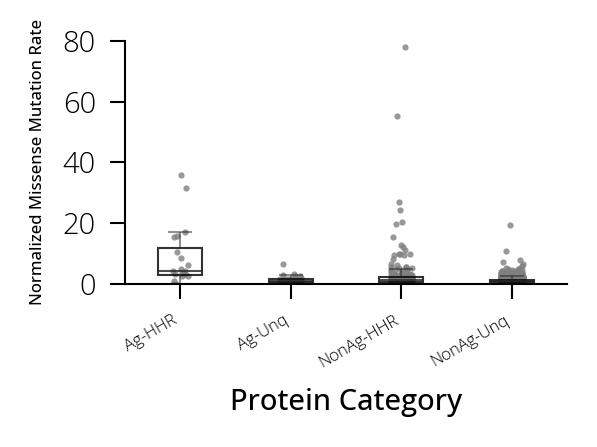

In [1017]:
GWMutR_fig, GWMutR_ax = plt.subplots(figsize=(2, 1.5))

in_GeneInfo_DF = Genes_GCandMutFreqStats_DF
X_Order = ['Antigen-HHR', 'Antigen-Unq',  'NonReactive-HHR', 'NonReactive-Unq',  ]

# 2) Strip
sns.stripplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF, color = "grey",
    zorder=0, s=1.5, alpha=0.8,
    ax = GWMutR_ax,
)

# 3) Box
sns.boxplot(
    x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
    order=X_Order, data=in_GeneInfo_DF,
    width=0.4, showcaps=True, fliersize=0,
    linewidth=0.5,
    boxprops={'facecolor':'none','edgecolor':'black','alpha':0.8},
    whiskerprops={'linewidth':0.5,'alpha':0.5},
    capprops={'linewidth':0.5,'alpha':0.5},
    medianprops={'linewidth':0.5,'alpha':0.8},
    ax = GWMutR_ax,
)

GWMutR_ax.set_ylim(0, 80)
GWMutR_ax.set_xlabel("Protein Category")
GWMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)


# Replace long x-axis labels with shorter ones
short_labels = [ 'Ag-HHR', 'Ag-Unq', 'NonAg-HHR', 'NonAg-Unq',]
GWMutR_ax.set_xticks(range(len(X_Order)))
GWMutR_ax.set_xticks(ticks=range(len(X_Order)), labels=short_labels, fontsize=4, rotation=30, ha='right')

sns.despine()

plt.show()

#### Show plot 

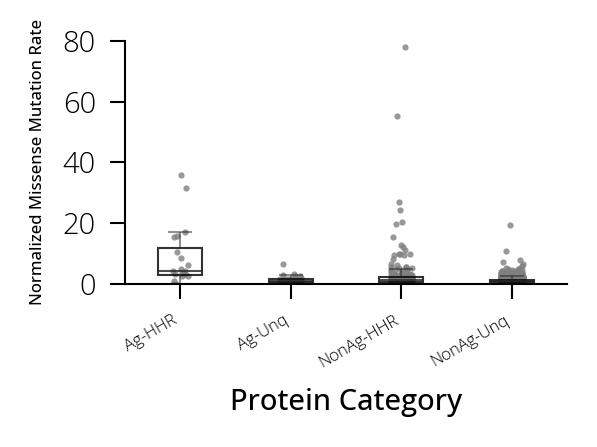

In [1018]:

GWMutR_fig

## Statistical Comparison of mutational burden (Genome-wide, 4 categories)


#### Look at distribution stats for each group (`Ag-HHR`, `NonAg-HHR`, `Ag-NonHHR`, `NonAg-NonHHR`)

In [1019]:
MutationBurdenPerGene_GroupStats_DF = Genes_GCandMutFreqStats_DF.groupby("AntigenLVL2_And_HHR_Comb")["RelFreq_NS_Muts"].describe().reset_index()

In [1020]:
MutationBurdenPerGene_GroupStats_DF

,AntigenLVL2_And_HHR_Comb,count,mean,std,min,25%,50%,75%,max
0,Antigen-HHR,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802
1,Antigen-Unq,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
2,NonReactive-HHR,204.0,3.005899,7.481313,0.0,0.598638,1.332993,2.317748,78.102190
3,NonReactive-Unq,3584.0,0.889619,0.813826,0.0,0.385914,0.763359,1.231527,19.251337


# Part 3: Focused mutational burden analysis of `HHR vs Non-HHR antigens`

## A) Compare OVERALL mutation burden between HHR and non-HHR antigens

The median mutational burden of HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA. <br>
The median mutational burden of Non-HHR antigens is 1 missense mutations (IQR: 0-2) per 100 AA. <br>
The mutational burden of HHR antigens is significantly higher than non-HHR antigens. <br>


In [1021]:
Antigen_GCandMutFreqStats_DF.groupby("HasHmRegion")["RelFreq_NS_Muts"].describe()

,count,mean,std,min,25%,50%,75%,max
HasHmRegion,,,,,,,,
False,33.0,1.215118,1.246859,0.0,0.492611,0.961538,1.508621,6.338028
True,20.0,8.621754,9.985787,0.0,2.933785,4.089168,11.736047,35.786802


In [1022]:
Antigen_NonHHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False")["RelFreq_NS_Muts"]
Antigen_HHR_RelFreq = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True")["RelFreq_NS_Muts"]


In [1023]:
# Wilcoxon rank-sum test
stat, p_value = ranksums(Antigen_NonHHR_RelFreq, Antigen_HHR_RelFreq)
# Output the result
print(f"Wilcoxon rank-sum test statistic: {stat}")
print(f"P-value: {p_value}") 

Wilcoxon rank-sum test statistic: -4.367156268334564
P-value: 1.2587467092606682e-05


In [1024]:
### The median mutational burden on HHR antigens is 4 missense mutations (IQR: 3-12) per 100 AA .
### This is significantly higher than the mutational burden on non-HHR antigens, with a median of 1 missense mutations (IQR: 0-2) per 100 AA


In [1025]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut != Has_mGCE_WiNSMut")

,Chrom,Start,End,Strand,Feature,H37rv_GeneID,Symbol,Functional_Category,Gene_Cat_V2,N_Pos,N_Neg,Total,Positive_Proportion,Middle,Length,AnyPosEpitope,Antigen_LVL2,N_HmRegion,HasHmRegion,AntigenLVL2_And_HHR_Comb,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE,Total_NS_Muts_BymGCE_InEpitope,Total_NS_Muts_BypGCE_InEpitope,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Has_mGCE,Has_mGCE_WiNSMut,Has_mGCE_WiNSMut_InEpitope,Has_pGCE,Has_pGCE_WiNSMut,Has_pGCE_WiNSMut_InEpitope,Length_WiPosEpitope,RelLength_WiPosEpitope
10,NC_000962.3,3376938,3378243,-,CDS,Rv3018c,PPE46,PE/PPE,PE/PPE,3,3,6,0.5,3377590.5,1305,True,True,1,True,Antigen-HHR,2,0,18.0,0.0,0.0,11.0,0.0,11.0,4.137931,0.0,False,False,False,True,True,True,135,0.103448


In [1026]:
Antigen_GCandMutFreqStats_DF.query("Total_NS_Muts_BymGCE != Total_NS_Muts_BypGCE").shape

(4, 38)

In [1027]:
Antigen_GCandMutFreqStats_DF.query("Has_pGCE_WiNSMut == True").shape

(10, 38)

In [1028]:
Antigen_GCandMutFreqStats_DF.query("Has_mGCE_WiNSMut == True").shape

(9, 38)

## B) Plot normalized mutation rate of HHR vs non-HHR antigens

#### Code to create plot

In [1029]:
!mkdir ./B_MutBurden_Results/

mkdir: cannot create directory ‘./B_MutBurden_Results/’: File exists


Seed: 134


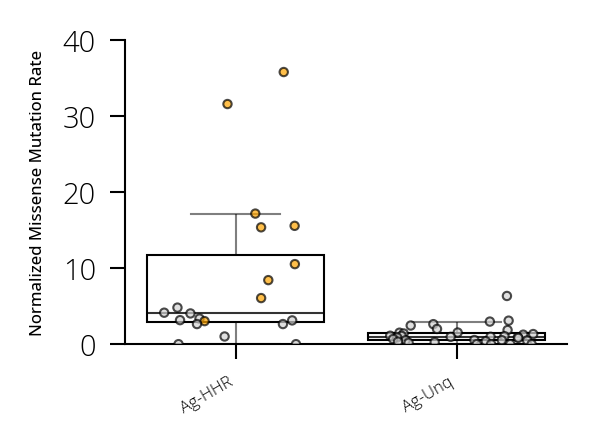

In [1030]:
# Create figure and axis
AMutR_fig, AMutR_ax = plt.subplots(figsize=(2, 1.5))

seed_i = 134
print("Seed:", seed_i)

np.random.seed(seed_i)
in_GeneInfo_DF = Antigen_GCandMutFreqStats_DF

X_Order = ['Antigen-HHR', 'Antigen-Unq']

Has_GC_EpiMut_Pallete = { True : "Orange",
                          False : "lightgrey", }


sns.stripplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
               order = X_Order, hue = "Has_mGCE_WiNSMut", palette = Has_GC_EpiMut_Pallete,
               jitter = 0.35,
               data=in_GeneInfo_DF, dodge=False,
               alpha = 0.7, size = 2,
               edgecolor="black", linewidth=0.5, ax = AMutR_ax,
               legend=False, )


sns.boxplot(x="AntigenLVL2_And_HHR_Comb", y="RelFreq_NS_Muts",
            order = X_Order,  
            data=in_GeneInfo_DF,
            legend=False, linewidth = 0.5, ax = AMutR_ax,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

# Y axis and labels
AMutR_ax.set_ylim(0, 40)
AMutR_ax.set_ylabel("Normalized Missense Mutation Rate", fontsize=4)
AMutR_ax.set_xlabel("")

# Replace long x-axis labels with shorter ones
short_labels = ['Ag-HHR', 'Ag-Unq']
AMutR_ax.set_xticks(range(len(X_Order)))
AMutR_ax.set_xticklabels(short_labels, fontsize=4, rotation=30, ha='right')

sns.despine(ax=AMutR_ax)

plt.tight_layout()

plt.show()



#### Show plot 

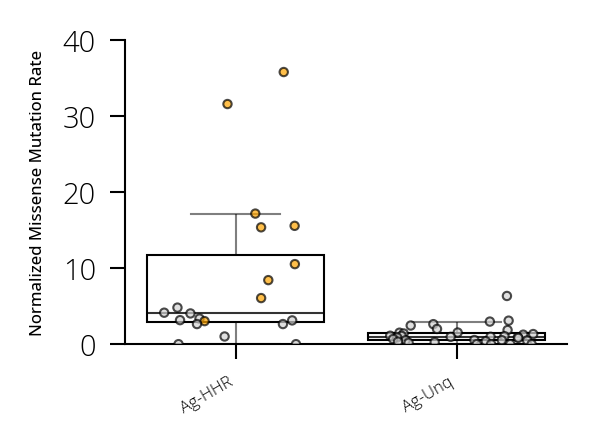

In [1031]:

AMutR_fig

### What are the top 10 antigens with the highest OVERALL mutational burden?

In [1032]:
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "N_Pos", "Total", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",   ]
# "Length", "H37rv_GeneID",
i_TarCols = [ "Symbol", "HasHmRegion", "RelFreq_NS_Muts", "pGCE_Ovrlap", "mGCE_Ovrlap", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "Total_NS_Muts_BymGCE",  "Total_NS_Muts_BypGCE",  ]

i_TarCols_V2 = [ "Symbol", "Length", "HasHmRegion", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", ]

Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V2].reset_index(drop=True)

,Symbol,Length,HasHmRegion,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope
0,PPE60,1182,True,35.786802,6.091371,141.0,24.0
1,esxL,285,True,31.578947,28.421053,30.0,27.0
2,esxP,297,True,17.171717,2.020202,17.0,2.0
3,PPE18,1176,True,15.561224,11.224490,61.0,44.0
4,PPE19,1191,True,15.365239,2.267003,61.0,9.0
5,esxO,285,True,10.526316,3.157895,10.0,3.0
6,esxN,285,True,8.421053,1.052632,8.0,1.0
7,Rv0010c,426,False,6.338028,1.408451,9.0,2.0
8,esxK,297,True,6.060606,3.030303,6.0,3.0
9,Rv3115,1248,True,4.807692,0.240385,20.0,1.0


In [1033]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


In [1034]:
Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(20)[i_TarCols].reset_index(drop=True)

,Symbol,HasHmRegion,RelFreq_NS_Muts,pGCE_Ovrlap,mGCE_Ovrlap,Total_NS_Muts,Total_NS_Muts_InEpitope,Total_NS_Muts_BymGCE,Total_NS_Muts_BypGCE
0,PPE60,True,35.786802,8,8,141.0,24.0,120.0,120.0
1,esxL,True,31.578947,10,7,30.0,27.0,13.0,20.0
2,esxP,True,17.171717,9,9,17.0,2.0,12.0,12.0
3,PPE18,True,15.561224,8,7,61.0,44.0,45.0,46.0
4,PPE19,True,15.365239,5,5,61.0,9.0,36.0,36.0
5,esxO,True,10.526316,5,5,10.0,3.0,6.0,6.0
6,esxN,True,8.421053,3,3,8.0,1.0,7.0,7.0
7,Rv0010c,False,6.338028,0,0,9.0,2.0,0.0,0.0
8,esxK,True,6.060606,5,3,6.0,3.0,1.0,3.0
9,Rv3115,True,4.807692,0,0,20.0,1.0,0.0,0.0


### Create table of top 5 HHR and Non-HHR antigens (Ranked by mut-burden in each group)

In [1035]:
i_TarCols_V3 = ["HasHmRegion", "Symbol", "Length", "RelFreq_NS_Muts", "RelFreq_NS_Mut_InEpitope", "Total_NS_Muts", "Total_NS_Muts_InEpitope", "pGCE_Ovrlap", "mGCE_Ovrlap",]

Top5_HHR_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == True").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)

Top5_UNQ_Antigen_GCandMutFreqStats_DF = Antigen_GCandMutFreqStats_DF.query("HasHmRegion == False").sort_values("RelFreq_NS_Muts", ascending=False).head(5)[i_TarCols_V3].reset_index(drop=True)


Top5HHR_Vs_Top5Unq_Antigens_Stats_DF = pd.concat([Top5_HHR_Antigen_GCandMutFreqStats_DF, Top5_UNQ_Antigen_GCandMutFreqStats_DF],
                                                 axis =0 )
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF.shape

(10, 9)

In [1036]:
Top5HHR_Vs_Top5Unq_Antigens_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
0,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
1,False,esxH,291,3.092784,3.092784,3.0,3.0,0,0
2,False,esxB,303,2.970297,2.970297,3.0,3.0,0,0
3,False,Rv2660c,228,2.631579,1.315789,2.0,1.0,0,0
4,False,rimJ,612,2.450980,0.490196,5.0,1.0,0,0


### Create table of top 10 antigens (Ranked by mut-burden)

In [1037]:
Top10MutBurden_Antigen_Stats_DF = Antigen_GCandMutFreqStats_DF.sort_values("RelFreq_NS_Muts", ascending=False).head(10)[i_TarCols_V3].reset_index(drop=True)
Top10MutBurden_Antigen_Stats_DF.shape

(10, 9)

In [1038]:
Top10MutBurden_Antigen_Stats_DF

,HasHmRegion,Symbol,Length,RelFreq_NS_Muts,RelFreq_NS_Mut_InEpitope,Total_NS_Muts,Total_NS_Muts_InEpitope,pGCE_Ovrlap,mGCE_Ovrlap
0,True,PPE60,1182,35.786802,6.091371,141.0,24.0,8,8
1,True,esxL,285,31.578947,28.421053,30.0,27.0,10,7
2,True,esxP,297,17.171717,2.020202,17.0,2.0,9,9
3,True,PPE18,1176,15.561224,11.224490,61.0,44.0,8,7
4,True,PPE19,1191,15.365239,2.267003,61.0,9.0,5,5
5,True,esxO,285,10.526316,3.157895,10.0,3.0,5,5
6,True,esxN,285,8.421053,1.052632,8.0,1.0,3,3
7,False,Rv0010c,426,6.338028,1.408451,9.0,2.0,0,0
8,True,esxK,297,6.060606,3.030303,6.0,3.0,5,3
9,True,Rv3115,1248,4.807692,0.240385,20.0,1.0,0,0


# Part 3: Analysis of GC events mutating MHC-II antigens & epitopes

## Basic questions to ask of GC events mutating epitopes/antigens

In [1039]:
mGCE_DF.shape

(213, 46)

In [1040]:
pGCE_DF.shape

(324, 46)

In [1041]:
#mGCE_DF.columns

In [1042]:
#mGCE_DF["N_EpiMutated_By_GCE"].value_counts()

In [1043]:
#pGCE_DF["N_EpiMutated_By_GCE"].value_counts()

### 1) How many pGC events cause any AA change? (183/324, 86%)

In [1044]:
pGCE_DF.shape

(324, 46)

In [1045]:
pGCE_WiNSMut_DF = pGCE_DF.query("N_NS_Mut > 0")
pGCE_WiNSMut_DF.shape

(280, 46)

In [1046]:
pGCE_WiNSMut_DF.shape[0] / pGCE_DF.shape[0]

0.8641975308641975

### 2) How many pGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (42/324, 13%)

In [1047]:
pGCE_InAntigen_DF = pGCE_DF.query("(Overlap_WiAntigenLVL2Gene == True) ")
pGCE_InAntigen_DF.shape

(48, 46)

In [1048]:
44/324


0.13580246913580246

In [1049]:
pGCE_WiNSMut_InAntigen_DF = pGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
pGCE_WiNSMut_InAntigen_DF.shape

(42, 46)

In [1050]:
pGCE_DF.shape

(324, 46)

In [1051]:
42/324

0.12962962962962962

In [1052]:
pGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 5
esxP                 3
esxK,esxL            3
PPE46                2
esxM,esxN            2
esxP,Rv2348c         2
PPE18,esxK,esxL      1
esxO,esxP,Rv2348c    1
esxO,esxP            1
esxO                 1
esxN                 1
Name: count, dtype: int64

In [1053]:
# How many unique HHRs? 7
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP
# PPE46
# esxM, esxN

# How many unique proteins? 10 (PPE18, PPE19, PPE60, esxK, esxL, esxO, esxP, esxM, esxN, PPE46)

### 3) How many pGC events mutate (AA change) an epitope (In L2 Antigen)? (25/324, 10%)

In [1054]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF = pGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [1055]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(25, 46)

In [1056]:
pGCE_DF.shape

(324, 46)

In [1057]:
25/324

0.07716049382716049

In [1058]:
pGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
esxL                 5
PPE60                5
esxK,esxL            3
PPE18,esxK,esxL      1
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

### Extras Questions for mGCEs only

#### 1) How many mGC events cause any AA change? (183/213, 86%)

In [1059]:
mGCE_WiNSMut_DF = mGCE_DF.query("N_NS_Mut > 0")
mGCE_WiNSMut_DF.shape

(183, 46)

In [1060]:
mGCE_WiNSMut_DF.shape[0] / mGCE_DF.shape[0]

0.8591549295774648

#### 3) How many mGC events cause any AA change IN AN ANTIGEN (`LVL2`)? (37/213, 17%)

In [1061]:
mGCE_DF.shape

(213, 46)

In [1062]:
mGCE_WiNSMut_InAntigen_DF = mGCE_DF.query("(N_NS_Mut > 0) & (Overlap_WiAntigenLVL2Gene == True) ")
mGCE_WiNSMut_InAntigen_DF.shape

(37, 46)

In [1063]:
37/213

0.17370892018779344

In [1064]:
mGCE_WiNSMut_InAntigen_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE60                8
PPE18                7
PPE19                5
esxL                 4
esxP                 3
esxK,esxL            2
esxM,esxN            2
esxP,Rv2348c         2
esxO,esxP            1
esxO                 1
esxN                 1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

#### How many mGC events mutate (AA change) an epitope (In L2 Antigen)? (22/213, 10%)

In [1065]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF = mGCE_WiNSMut_InAntigen_DF.query("N_EpiMutated_By_GCE > 0")

In [1066]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF.shape

(22, 46)

In [1067]:
mGCE_DF.shape

(213, 46)

In [1068]:
mGCE_V3_WiNSMut_InAntigen_InEpi_DF["Overlap_Genes"].value_counts()

Overlap_Genes
PPE18                7
PPE60                5
esxL                 4
esxK,esxL            2
PPE19                1
esxO                 1
esxO,esxP            1
esxO,esxP,Rv2348c    1
Name: count, dtype: int64

In [1069]:
# How many unique regions/ groups of genes? 5
# PPE18
# PPE19
# PPE60
# esxK, esxL
# esxO, esxP



# QC Mut Burden per epitope data for `pepA`

In [1070]:
RvPerCodon_NSMutFreq_DF.shape 


(12132, 4)

In [1071]:
Rv_EpitopeCov_NonZero_DF.shape

(746901, 5)

### Get all `pepA` mutation counts per codon + mutation events

In [1072]:
pepA_Codon_NSMutFreq_DF = RvPerCodon_NSMutFreq_DF.query("Symbol == 'pepA'")
pepA_Codon_NSMutFreq_DF.shape

(5, 4)

In [1073]:
pepA_Codon_NSMutFreq_DF

,Symbol,Codon,Mutation_Count,Pos_0based
10487,pepA,8.0,1,151168
10488,pepA,10.0,1,151176
10489,pepA,76.0,1,151372
10490,pepA,236.0,1,151852
10491,pepA,256.0,1,151913


In [1074]:
Gub_SNPs_pepA_DF = Gub_SNPs_V2_DF.query("Symbol == 'pepA'")
Gub_SNPs_pepA_DF.shape

(7, 23)

In [1075]:
Gub_SNPs_pepA_DF

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
1652,151798,Node_125,Node_124,A,G,NaN,151797,NC_000962.3,0,0,Unq,1,pepA,+,650.0,217.0,3.0,NaN,NaN,151797,151798,lineage2,0
7093,151363,Node_145,Node_144,C,T,NaN,151362,NC_000962.3,0,0,Unq,1,pepA,+,215.0,72.0,3.0,NaN,NaN,151362,151363,lineage1,1
11878,151177,Node_20,Node_19,G,C,NaN,151176,NC_000962.3,0,0,Unq,1,pepA,+,29.0,10.0,3.0,R,S,151176,151177,lineage4,0
15744,151373,Node_37,01_R1430,G,A,NaN,151372,NC_000962.3,0,0,Unq,1,pepA,+,225.0,76.0,1.0,V,M,151372,151373,lineage4,0
18172,151853,Node_42,mada_2-25,G,T,NaN,151852,NC_000962.3,0,0,Unq,1,pepA,+,705.0,236.0,1.0,G,W,151852,151853,lineage4,0
20043,151914,Node_52,R23571,G,A,NaN,151913,NC_000962.3,0,0,Unq,1,pepA,+,766.0,256.0,2.0,G,D,151913,151914,lineage4,0
20769,151169,Node_57,Node_56,T,G,NaN,151168,NC_000962.3,0,0,Unq,1,pepA,+,21.0,8.0,1.0,S,A,151168,151169,lineage4,0


### Get all `pepA` epitope/peptide info

In [1076]:
LPM_AllPep_V2_DF.shape

(18741, 31)

In [1077]:
pepA_AllPep_DF = LPM_AllPep_V2_DF.query("Symbol == 'pepA'")
pepA_AllPep_DF.shape

(72, 31)

In [1078]:
pepA_PosEpi_DF = LPM_AllPep_V2_DF.query("Symbol == 'pepA' & PosEpitope_Any == True")
pepA_PosEpi_DF.shape

(3, 31)

### Compare overlap of `pepA` mutations with epitopes (Look good! Passed QC)

In [1079]:
pepA_PosEpi_DF

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
345,UnqPeptide_346,PQVVNINTKLGYNNA,15,Rv0125,pepA,60,75,NC_000962.3,151327,151372,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_346-pepA,0,False,True,0,0,False,0,False,0,.,0,.,Positive
419,UnqPeptide_420,VAQVGPQVVNINTKL,15,Rv0125,pepA,55,70,NC_000962.3,151312,151357,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_420-pepA,0,False,True,0,0,False,0,False,0,.,0,.,Positive
4646,UnqPeptide_4627,SVLAAVGLGLATAPA,15,Rv0125,pepA,15,30,NC_000962.3,151192,151237,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_4627-pepA,0,False,True,0,0,False,0,False,0,.,0,.,Positive


In [1080]:
Gub_SNPs_pepA_DF

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
1652,151798,Node_125,Node_124,A,G,NaN,151797,NC_000962.3,0,0,Unq,1,pepA,+,650.0,217.0,3.0,NaN,NaN,151797,151798,lineage2,0
7093,151363,Node_145,Node_144,C,T,NaN,151362,NC_000962.3,0,0,Unq,1,pepA,+,215.0,72.0,3.0,NaN,NaN,151362,151363,lineage1,1
11878,151177,Node_20,Node_19,G,C,NaN,151176,NC_000962.3,0,0,Unq,1,pepA,+,29.0,10.0,3.0,R,S,151176,151177,lineage4,0
15744,151373,Node_37,01_R1430,G,A,NaN,151372,NC_000962.3,0,0,Unq,1,pepA,+,225.0,76.0,1.0,V,M,151372,151373,lineage4,0
18172,151853,Node_42,mada_2-25,G,T,NaN,151852,NC_000962.3,0,0,Unq,1,pepA,+,705.0,236.0,1.0,G,W,151852,151853,lineage4,0
20043,151914,Node_52,R23571,G,A,NaN,151913,NC_000962.3,0,0,Unq,1,pepA,+,766.0,256.0,2.0,G,D,151913,151914,lineage4,0
20769,151169,Node_57,Node_56,T,G,NaN,151168,NC_000962.3,0,0,Unq,1,pepA,+,21.0,8.0,1.0,S,A,151168,151169,lineage4,0


In [1081]:
pepA_PosEpi_DF.query("Epitope_ID == 'UnqPeptide_346' ")

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
345,UnqPeptide_346,PQVVNINTKLGYNNA,15,Rv0125,pepA,60,75,NC_000962.3,151327,151372,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_346-pepA,0,False,True,0,0,False,0,False,0,.,0,.,Positive


In [1082]:
Gub_SNPs_pepA_DF.query("Pos_1based == 151373")

,Pos_1based,Parent_Node,Child_Node,Parent_Call,Child_Call,EventID,Pos_0based,Chrom,NumHmOvrlap,HmOvrlap,RegionType,N_OverlapGenes,Symbol,Strand,Gene_Pos_0,Codon,Codon_Pos,Ref_AA,Mut_AA,Start,End,Lineage,N_Epitopes_Overlap
15744,151373,Node_37,01_R1430,G,A,NaN,151372,NC_000962.3,0,0,Unq,1,pepA,+,225.0,76.0,1.0,V,M,151372,151373,lineage4,0


# Part X: Eval correlation between mut burden in epitopes vs negative peptides

In [1083]:
from scipy.stats import mannwhitneyu


In [1084]:
LPM_AllPep_V2_DF.head()

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity
0,UnqPeptide_1,FPTLNYAVSVAEACE,15,Rv0322,udgA,368,383,NC_000962.3,390363,390408,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_1-udgA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
1,UnqPeptide_2,ERIPKFAHLPTVLGE,15,Rv2992c,gltS,238,253,NC_000962.3,3349518,3349563,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_2-gltS,0,False,False,2,0,False,0,False,0,.,0,.,Negative
2,UnqPeptide_3,FPGVLVAARPVGMFR,15,Rv3628,ppa,66,81,NC_000962.3,4067620,4067665,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_3-ppa,0,False,False,0,0,False,0,False,0,.,0,.,Negative
3,UnqPeptide_4,GDPARTMRRMIGGLR,15,Rv3617,ephA,167,182,NC_000962.3,4058233,4058278,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_4-ephA,0,False,False,0,0,False,0,False,0,.,0,.,Negative
4,UnqPeptide_5,LLPYSYDDLDFNALL,15,Rv1282c,oppC,40,55,NC_000962.3,1435978,1436023,1,Lindestam16_Panda24_Merged,True,False,False,False,False,UnqPeptide_5-oppC,0,False,False,0,0,False,0,False,0,.,0,.,Negative


## A) `All L2 Antigens` (N = 53)

#### Subset for all peptides assayed in LvL2 Antigens

In [1085]:
LPM_AllPep_V2_InL2Antigen_DF = LPM_AllPep_V2_DF.query("Antigen_LVL2 == True")

LPM_AllPep_V2_InL2Antigen_DF["Epitope_Status_Label"] = LPM_AllPep_V2_InL2Antigen_DF["PosEpitope_Any"].map({True: "Positive Epitope", False: "Negative Peptide"})

# Define POSITIVE EPITOPES ONLY
LPM_PosEpi_V2_InL2Antigen_DF = LPM_AllPep_V2_InL2Antigen_DF.query("PosEpitope_Any == True")


# Classify all peptides by whether they overlap with any known positive epitope
LPM_AllPep_V2_InL2Antigen_DF = bf.count_overlaps(LPM_AllPep_V2_InL2Antigen_DF,
                                                 LPM_PosEpi_V2_InL2Antigen_DF,
                                              cols1 = ["Chrom", "Rv_Start", "Rv_End"],
                                              cols2 = ["Chrom", "Rv_Start", "Rv_End"],)

LPM_AllPep_V2_InL2Antigen_DF = LPM_AllPep_V2_InL2Antigen_DF.rename(columns={"count": "N_Ovrlap_PosEpi"})

LPM_AllPep_V2_InL2Antigen_DF["Ovrlap_PosEpi"] = LPM_AllPep_V2_InL2Antigen_DF["N_Ovrlap_PosEpi"] > 0

LPM_AllPep_V2_InL2Antigen_DF["Reactivity_WiPosOvrlap"] = LPM_AllPep_V2_InL2Antigen_DF["Reactivity"] + "-" + LPM_AllPep_V2_InL2Antigen_DF["Ovrlap_PosEpi"].astype(str)  

LPM_AllPep_V2_InL2Antigen_DF.shape


/tmp/ipykernel_2280809/1345304370.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LPM_AllPep_V2_InL2Antigen_DF["Epitope_Status_Label"] = LPM_AllPep_V2_InL2Antigen_DF["PosEpitope_Any"].map({True: "Positive Epitope", False: "Negative Peptide"})


(924, 35)

In [1086]:
LPM_AllPep_V2_InL2Antigen_DF["Symbol"].nunique()

53

In [1087]:
LPM_AllPep_V2_InL2Antigen_DF["Reactivity_WiPosOvrlap"].value_counts()

Reactivity_WiPosOvrlap
Negative-False    362
Positive-True     342
Negative-True     220
Name: count, dtype: int64

### Do stats test between groups

In [1088]:

# Extract values for each group
i_NS_Muts_PosEpi_G1 = LPM_AllPep_V2_InL2Antigen_DF.query("Reactivity_WiPosOvrlap == 'Positive-True' ")["N_NSMut_Total"]
i_NS_Muts_NenPep_G2 =  LPM_AllPep_V2_InL2Antigen_DF.query("Reactivity_WiPosOvrlap == 'Negative-False'")["N_NSMut_Total"]

# Perform the Wilcoxon rank-sum test (Mann–Whitney U)
stat, p_value = mannwhitneyu(i_NS_Muts_PosEpi_G1,
                             i_NS_Muts_NenPep_G2,
                             alternative="greater")

print(f"Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:\n")
print(f"Mann–Whitney U statistic: {stat}")
print(f"p-value: {p_value}")

LPM_AllPep_V2_InL2Antigen_DF.groupby("Reactivity_WiPosOvrlap")["N_NSMut_Total"].describe()

Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:

Mann–Whitney U statistic: 65970.5
p-value: 0.02132261582517681


,count,mean,std,min,25%,50%,75%,max
Reactivity_WiPosOvrlap,,,,,,,,
Negative-False,362.0,0.488950,1.586347,0.0,0.0,0.0,0.0,14.0
Negative-True,220.0,0.745455,1.610107,0.0,0.0,0.0,1.0,8.0
Positive-True,342.0,0.690058,2.042902,0.0,0.0,0.0,1.0,24.0


### Make boxplot + stripplot to compare distributions

/tmp/ipykernel_2280809/3635591783.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=LPM_AllPep_V2_InL2Antigen_DF,


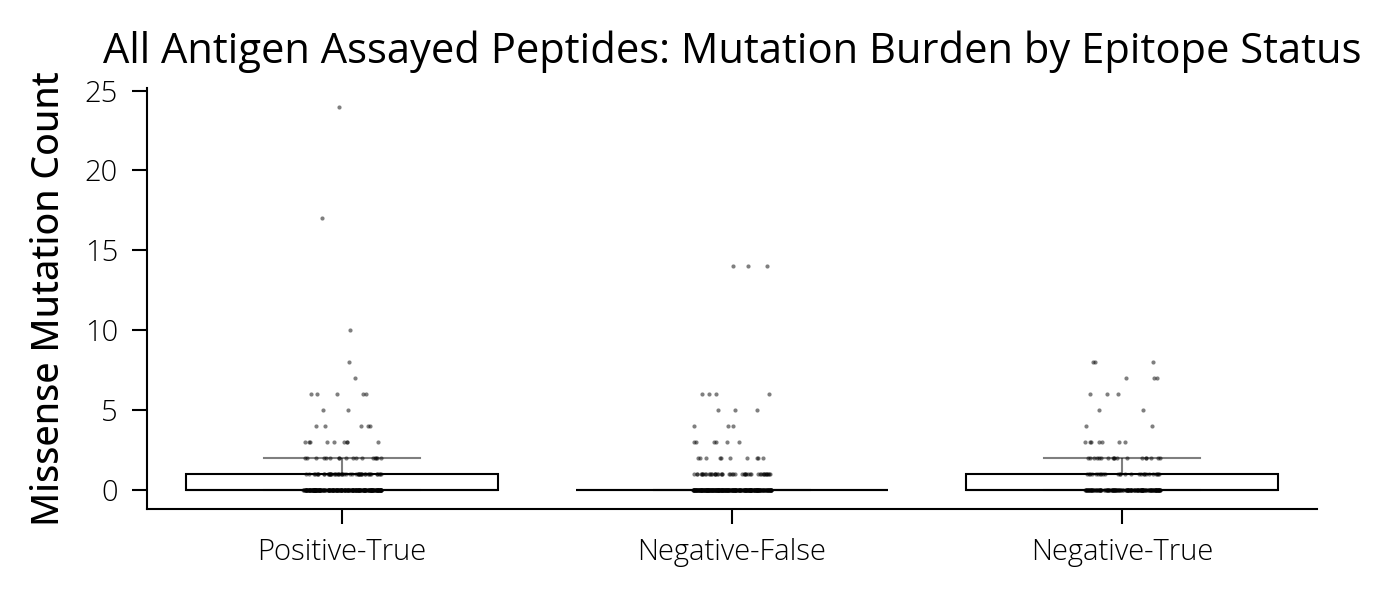

In [1089]:
# Visualization: Boxplot grouped by epitope status
plt.figure(figsize=(4.5, 2))

sns.boxplot(data=LPM_AllPep_V2_InL2Antigen_DF,
            x="Reactivity_WiPosOvrlap",
            y="N_NSMut_Total", 
            palette="Set2",
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

sns.stripplot(data=LPM_AllPep_V2_InL2Antigen_DF,
              x="Reactivity_WiPosOvrlap",
              y="N_NSMut_Total",
              color="black",
              size=1,
              alpha=0.5)

plt.xlabel("")
plt.ylabel("Missense Mutation Count", fontsize=9)
plt.title("All Antigen Assayed Peptides: Mutation Burden by Epitope Status", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## B) `All HHR-Antigens` (n = 20)

In [1090]:
LPM_AllPep_V2_InHHRAntigen_DF = LPM_AllPep_V2_InL2Antigen_DF.query("HasHmRegion == True")
LPM_AllPep_V2_InHHRAntigen_DF.shape


(345, 35)

In [1091]:
LPM_AllPep_V2_InHHRAntigen_DF["Symbol"].nunique()

20

### Do stats test between groups

In [1092]:

# Extract values for each group
i_NS_Muts_PosEpi_G1 = LPM_AllPep_V2_InHHRAntigen_DF.query("Reactivity_WiPosOvrlap == 'Positive-True' ")["N_NSMut_Total"]
i_NS_Muts_NenPep_G2 =  LPM_AllPep_V2_InHHRAntigen_DF.query("Reactivity_WiPosOvrlap == 'Negative-False'")["N_NSMut_Total"]

# Perform the Wilcoxon rank-sum test (Mann–Whitney U)
stat, p_value = mannwhitneyu(i_NS_Muts_PosEpi_G1,
                             i_NS_Muts_NenPep_G2,
                             alternative="greater")

print(f"Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:\n")
print(f"Mann–Whitney U statistic: {stat}")
print(f"p-value: {p_value}")

LPM_AllPep_V2_InHHRAntigen_DF.groupby("Reactivity_WiPosOvrlap")["N_NSMut_Total"].describe()

Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:

Mann–Whitney U statistic: 5140.5
p-value: 0.9949665013509194


,count,mean,std,min,25%,50%,75%,max
Reactivity_WiPosOvrlap,,,,,,,,
Negative-False,75.0,1.800000,3.066823,0.0,0.0,0.0,2.0,14.0
Negative-True,103.0,1.378641,2.128778,0.0,0.0,0.0,2.0,8.0
Positive-True,167.0,1.143713,2.809784,0.0,0.0,0.0,1.0,24.0


### Make boxplot + stripplot to compare distributions

/tmp/ipykernel_2280809/1408455552.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=LPM_AllPep_V2_InHHRAntigen_DF,


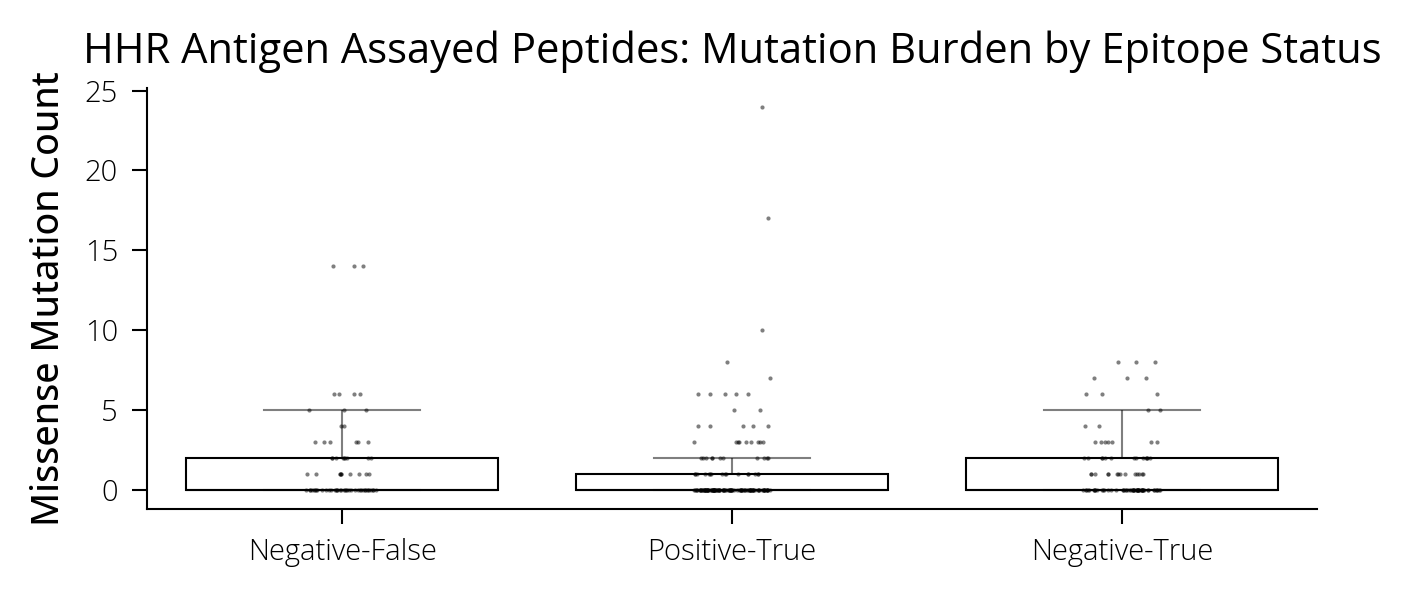

In [1093]:
# Visualization: Boxplot grouped by epitope status
plt.figure(figsize=(4.5, 2))

sns.boxplot(data=LPM_AllPep_V2_InHHRAntigen_DF,
            x="Reactivity_WiPosOvrlap",
            y="N_NSMut_Total", 
            palette="Set2",
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

sns.stripplot(data=LPM_AllPep_V2_InHHRAntigen_DF,
              x="Reactivity_WiPosOvrlap",
              y="N_NSMut_Total",
              color="black",
              size=1,
              alpha=0.5)

plt.xlabel("")
plt.ylabel("Missense Mutation Count", fontsize=9)
plt.title("HHR Antigen Assayed Peptides: Mutation Burden by Epitope Status", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

## C) `All peptides from PPE18` (n = 1)

In [1094]:
LPM_AllPep_V2_InPPE18_DF = LPM_AllPep_V2_InHHRAntigen_DF.query("Symbol == 'PPE18'")  
LPM_AllPep_V2_InPPE18_DF.shape  

(82, 35)

In [1095]:
LPM_AllPep_V2_InPPE18_DF["Symbol"].nunique()

1

### Do stats test between groups

In [1096]:

# Extract values for each group
i_NS_Muts_PosEpi_G1 = LPM_AllPep_V2_InPPE18_DF.query("Reactivity_WiPosOvrlap == 'Positive-True' ")["N_NSMut_Total"]
i_NS_Muts_NenPep_G2 =  LPM_AllPep_V2_InPPE18_DF.query("Reactivity_WiPosOvrlap == 'Negative-False'")["N_NSMut_Total"]

# Perform the Wilcoxon rank-sum test (Mann–Whitney U)
stat, p_value = mannwhitneyu(i_NS_Muts_PosEpi_G1,
                             i_NS_Muts_NenPep_G2,
                             alternative="greater")

print(f"Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:\n")
print(f"Mann–Whitney U statistic: {stat}")
print(f"p-value: {p_value}")

LPM_AllPep_V2_InPPE18_DF.groupby("Reactivity_WiPosOvrlap")["N_NSMut_Total"].describe()

Mann–Whitney U Test - Comparing mutational burden of positive epitopes versus negative peptides - Across All L2 Antigens:

Mann–Whitney U statistic: 386.5
p-value: 0.06777170421192454


,count,mean,std,min,25%,50%,75%,max
Reactivity_WiPosOvrlap,,,,,,,,
Negative-False,23.0,1.739130,1.543826,0.0,0.50,2.0,2.5,5.0
Negative-True,32.0,2.562500,2.395392,0.0,0.75,2.0,4.0,8.0
Positive-True,27.0,2.851852,2.413164,0.0,0.50,3.0,5.0,7.0


### Make boxplot + stripplot to compare distributions

/tmp/ipykernel_2280809/1665930939.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=LPM_AllPep_V2_InPPE18_DF,


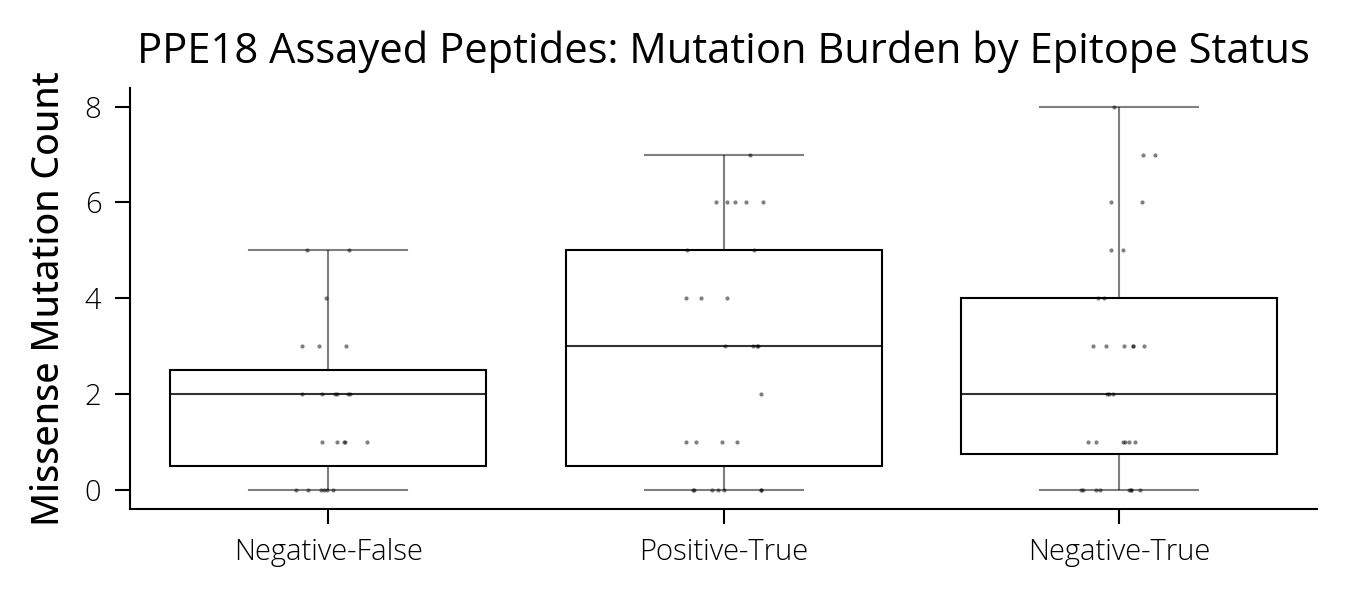

In [1097]:
# Visualization: Boxplot grouped by epitope status
plt.figure(figsize=(4.5, 2))

sns.boxplot(data=LPM_AllPep_V2_InPPE18_DF,
            x="Reactivity_WiPosOvrlap",
            y="N_NSMut_Total", 
            palette="Set2",
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

sns.stripplot(data=LPM_AllPep_V2_InPPE18_DF,
              x="Reactivity_WiPosOvrlap",
              y="N_NSMut_Total",
              color="black",
              size=1,
              alpha=0.5)

plt.xlabel("")
plt.ylabel("Missense Mutation Count", fontsize=9)
plt.title("PPE18 Assayed Peptides: Mutation Burden by Epitope Status", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

/tmp/ipykernel_2280809/1121432326.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=LPM_AllPep_V2_InPPE18_DF.query("Reactivity_WiPosOvrlap != 'Negative-True'"),


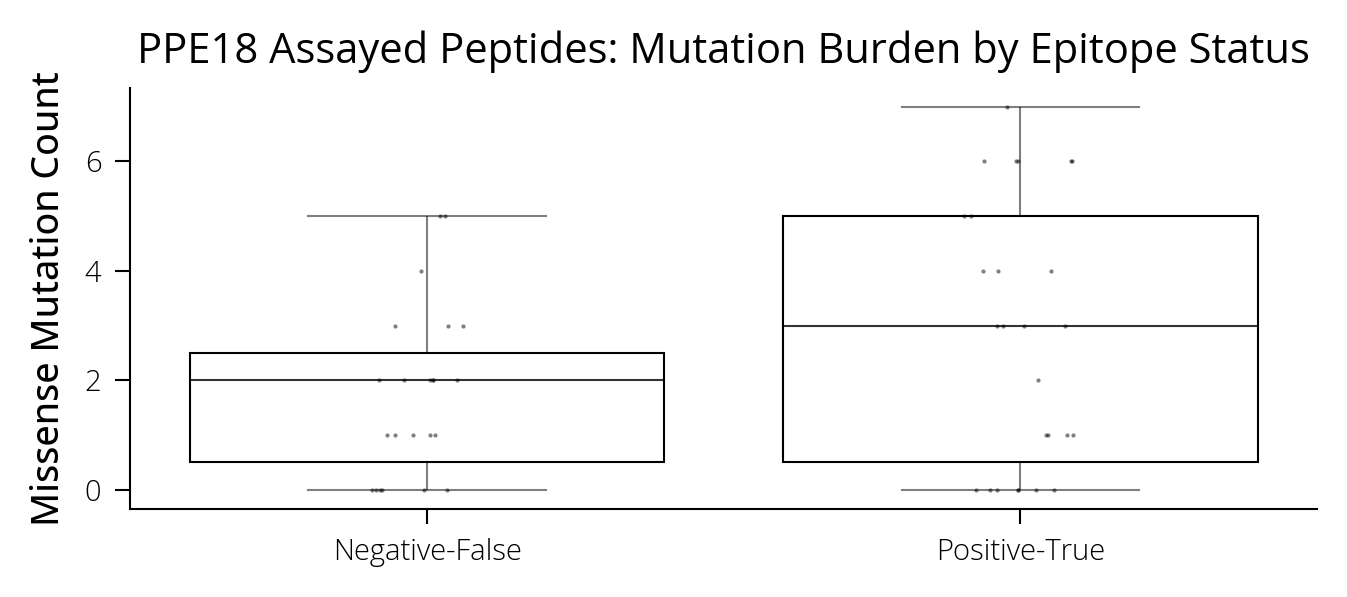

In [1161]:
# Visualization: Boxplot grouped by epitope status
plt.figure(figsize=(4.5, 2))

sns.boxplot(data=LPM_AllPep_V2_InPPE18_DF.query("Reactivity_WiPosOvrlap != 'Negative-True'"),
            x="Reactivity_WiPosOvrlap",
            y="N_NSMut_Total", 
            palette="Set2",
            legend=False, linewidth = 0.5,
            showcaps=True, fliersize=0, width = 0.8,
            boxprops={'facecolor': 'none', 'edgecolor': 'black', 'alpha': 1},
            whiskerprops={'color': 'black', 'alpha': 0.5},
            capprops={'color': 'black', 'alpha': 0.5},
            medianprops={'color': 'black', 'alpha': 0.8})

sns.stripplot(data=LPM_AllPep_V2_InPPE18_DF.query("Reactivity_WiPosOvrlap != 'Negative-True'"),
              x="Reactivity_WiPosOvrlap",
              y="N_NSMut_Total",
              color="black",
              size=1,
              alpha=0.5)

plt.xlabel("")
plt.ylabel("Missense Mutation Count", fontsize=9)
plt.title("PPE18 Assayed Peptides: Mutation Burden by Epitope Status", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

# Analysis of epitope mutation enrichment per antigen

In [1098]:
Antigen_GCandMutFreqStats_DF.columns

Index(['Chrom', 'Start', 'End', 'Strand', 'Feature', 'H37rv_GeneID', 'Symbol', 'Functional_Category', 'Gene_Cat_V2', 'N_Pos', 'N_Neg', 'Total', 'Positive_Proportion', 'Middle', 'Length', 'AnyPosEpitope', 'Antigen_LVL2', 'N_HmRegion', 'HasHmRegion', 'AntigenLVL2_And_HHR_Comb', 'pGCE_Ovrlap', 'mGCE_Ovrlap', 'Total_NS_Muts', 'Total_NS_Muts_InEpitope', 'Total_NS_Muts_BymGCE', 'Total_NS_Muts_BypGCE', 'Total_NS_Muts_BymGCE_InEpitope', 'Total_NS_Muts_BypGCE_InEpitope', 'RelFreq_NS_Muts', 'RelFreq_NS_Mut_InEpitope', 'Has_mGCE', 'Has_mGCE_WiNSMut', 'Has_mGCE_WiNSMut_InEpitope', 'Has_pGCE', 'Has_pGCE_WiNSMut', 'Has_pGCE_WiNSMut_InEpitope', 'Length_WiPosEpitope', 'RelLength_WiPosEpitope'], dtype='object')

In [1099]:
from scipy.stats import binomtest

In [1100]:
Antigen_EpiMutEnrichCols = ['H37rv_GeneID', 'Symbol', 'AntigenLVL2_And_HHR_Comb', #'HasHmRegion',
                            'N_Pos', 'N_Neg', 'Total', #'Positive_Proportion',
                            'Total_NS_Muts', 'Total_NS_Muts_InEpitope', 'Length', 
                            'Length_WiPosEpitope',]  #'Epitope_Length_Frac', 'Expected_NS_Muts_InEpitope']

antigen_EpiMutEnrich_DF = Antigen_GCandMutFreqStats_DF[Antigen_EpiMutEnrichCols]

antigen_EpiMutEnrich_DF["Epitope_Length_Frac"]        = antigen_EpiMutEnrich_DF["Length_WiPosEpitope"] / antigen_EpiMutEnrich_DF["Length"]
antigen_EpiMutEnrich_DF["Expected_NS_Muts_InEpitope"] = antigen_EpiMutEnrich_DF["Total_NS_Muts"] * antigen_EpiMutEnrich_DF["Epitope_Length_Frac"]


antigen_EpiMutEnrich_DF["Binom_Pval"] = antigen_EpiMutEnrich_DF.apply(
    lambda row: binomtest(
        int(row["Total_NS_Muts_InEpitope"]),
        n=int(row["Total_NS_Muts"]),
        p=row["Epitope_Length_Frac"]
    ).pvalue if row["Total_NS_Muts"] > 0 else np.nan,
    axis=1
)

/tmp/ipykernel_2280809/2634461015.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  antigen_EpiMutEnrich_DF["Epitope_Length_Frac"]        = antigen_EpiMutEnrich_DF["Length_WiPosEpitope"] / antigen_EpiMutEnrich_DF["Length"]
/tmp/ipykernel_2280809/2634461015.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  antigen_EpiMutEnrich_DF["Expected_NS_Muts_InEpitope"] = antigen_EpiMutEnrich_DF["Total_NS_Muts"] * antigen_EpiMutEnrich_DF["Epitope_Length_Frac"]
/tmp/ipykernel_2280809/2634461015.py:12: SettingWithCop

In [1101]:
antigen_EpiMutEnrich_DF.query("Symbol == 'PPE18'")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
3,Rv1196,PPE18,Antigen-HHR,27,56,83,61.0,44.0,1176,705,0.59949,36.568878,0.066433


In [1102]:
antigen_EpiMutEnrich_DF.query("Symbol == 'pepA'")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
26,Rv0125,pepA,Antigen-Unq,3,69,72,5.0,0.0,1068,105,0.098315,0.491573,1.0


In [1103]:
antigen_EpiMutEnrich_DF.query("Symbol == 'esxL'")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
1,Rv1198,esxL,Antigen-HHR,9,7,16,30.0,27.0,285,225,0.789474,23.684211,0.179047


In [1104]:
antigen_EpiMutEnrich_DF.query("Symbol == 'Rv0010c'")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
7,Rv0010c,Rv0010c,Antigen-Unq,2,4,6,9.0,2.0,426,48,0.112676,1.014085,0.26931


In [1105]:
antigen_EpiMutEnrich_DF.query("Total_NS_Muts >= 10 & Binom_Pval < 0.05")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
2,Rv2347c,esxP,Antigen-HHR,10,6,16,17.0,2.0,297,210,0.707071,12.020202,7.183808e-07
4,Rv1361c,PPE19,Antigen-HHR,16,21,37,61.0,9.0,1191,390,0.327456,19.974811,2.371727e-03
5,Rv2346c,esxO,Antigen-HHR,9,1,10,10.0,3.0,285,225,0.789474,7.894737,1.197091e-03
12,Rv2512c,Rv2512c,Antigen-HHR,3,5,8,14.0,8.0,1248,135,0.108173,1.514423,3.076224e-05
14,Rv3023c,Rv3023c,Antigen-HHR,3,5,8,13.0,4.0,1248,135,0.108173,1.406250,4.396482e-02


In [1106]:
antigen_EpiMutEnrich_DF.query("Total_NS_Muts >= 10 & Binom_Pval < 0.1")

,H37rv_GeneID,Symbol,AntigenLVL2_And_HHR_Comb,N_Pos,N_Neg,Total,Total_NS_Muts,Total_NS_Muts_InEpitope,Length,Length_WiPosEpitope,Epitope_Length_Frac,Expected_NS_Muts_InEpitope,Binom_Pval
2,Rv2347c,esxP,Antigen-HHR,10,6,16,17.0,2.0,297,210,0.707071,12.020202,7.183808e-07
3,Rv1196,PPE18,Antigen-HHR,27,56,83,61.0,44.0,1176,705,0.599490,36.568878,6.643331e-02
4,Rv1361c,PPE19,Antigen-HHR,16,21,37,61.0,9.0,1191,390,0.327456,19.974811,2.371727e-03
5,Rv2346c,esxO,Antigen-HHR,9,1,10,10.0,3.0,285,225,0.789474,7.894737,1.197091e-03
12,Rv2512c,Rv2512c,Antigen-HHR,3,5,8,14.0,8.0,1248,135,0.108173,1.514423,3.076224e-05
14,Rv3023c,Rv3023c,Antigen-HHR,3,5,8,13.0,4.0,1248,135,0.108173,1.406250,4.396482e-02


# Part Z: Regression of positivity fraction w/

# Load netMHCpanII results for `PPE18`

In [1107]:
# Load epitope prediction results
PPE18_netMHCII_Pred_DF = pd.read_csv("./netMHCpanII.PPE18.predict_result.csv")
PPE18_netMHCII_Pred_DF.shape


(10179, 9)

In [1108]:
PPE18_netMHCII_StrongBinders_DF =   PPE18_netMHCII_Pred_DF[PPE18_netMHCII_Pred_DF["rank"] < 2.0].copy()
PPE18_netMHCII_StrongBinders_DF.shape

(225, 9)

In [1109]:
ppe18_AA_length = 392
# Initialize array for coverage
coverage_array = [0] * ppe18_AA_length

# Count coverage at all overlapping positions
for _, row in PPE18_netMHCII_StrongBinders_DF.iterrows():
    for pos in range(row["start"], row["end"] + 1):
        if 1 <= pos <= ppe18_AA_length:
            coverage_array[pos - 1] += 1

# Build coverage DataFrame
PPE18_netMHC_SB_Cov_DF = pd.DataFrame({
    "Codon": range(1, ppe18_AA_length + 1),
    "netMHCpan_Strong_Binder_Ct": coverage_array
})



In [1110]:
PPE18_netMHC_SB_Cov_DF.shape

(392, 2)

In [1111]:
PPE18_netMHC_SB_Cov_DF.head()

,Codon,netMHCpan_Strong_Binder_Ct
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [1112]:
1176 / 3

392.0

#### Gen simple NetMHCpan Strong Binder Cov for PPE18

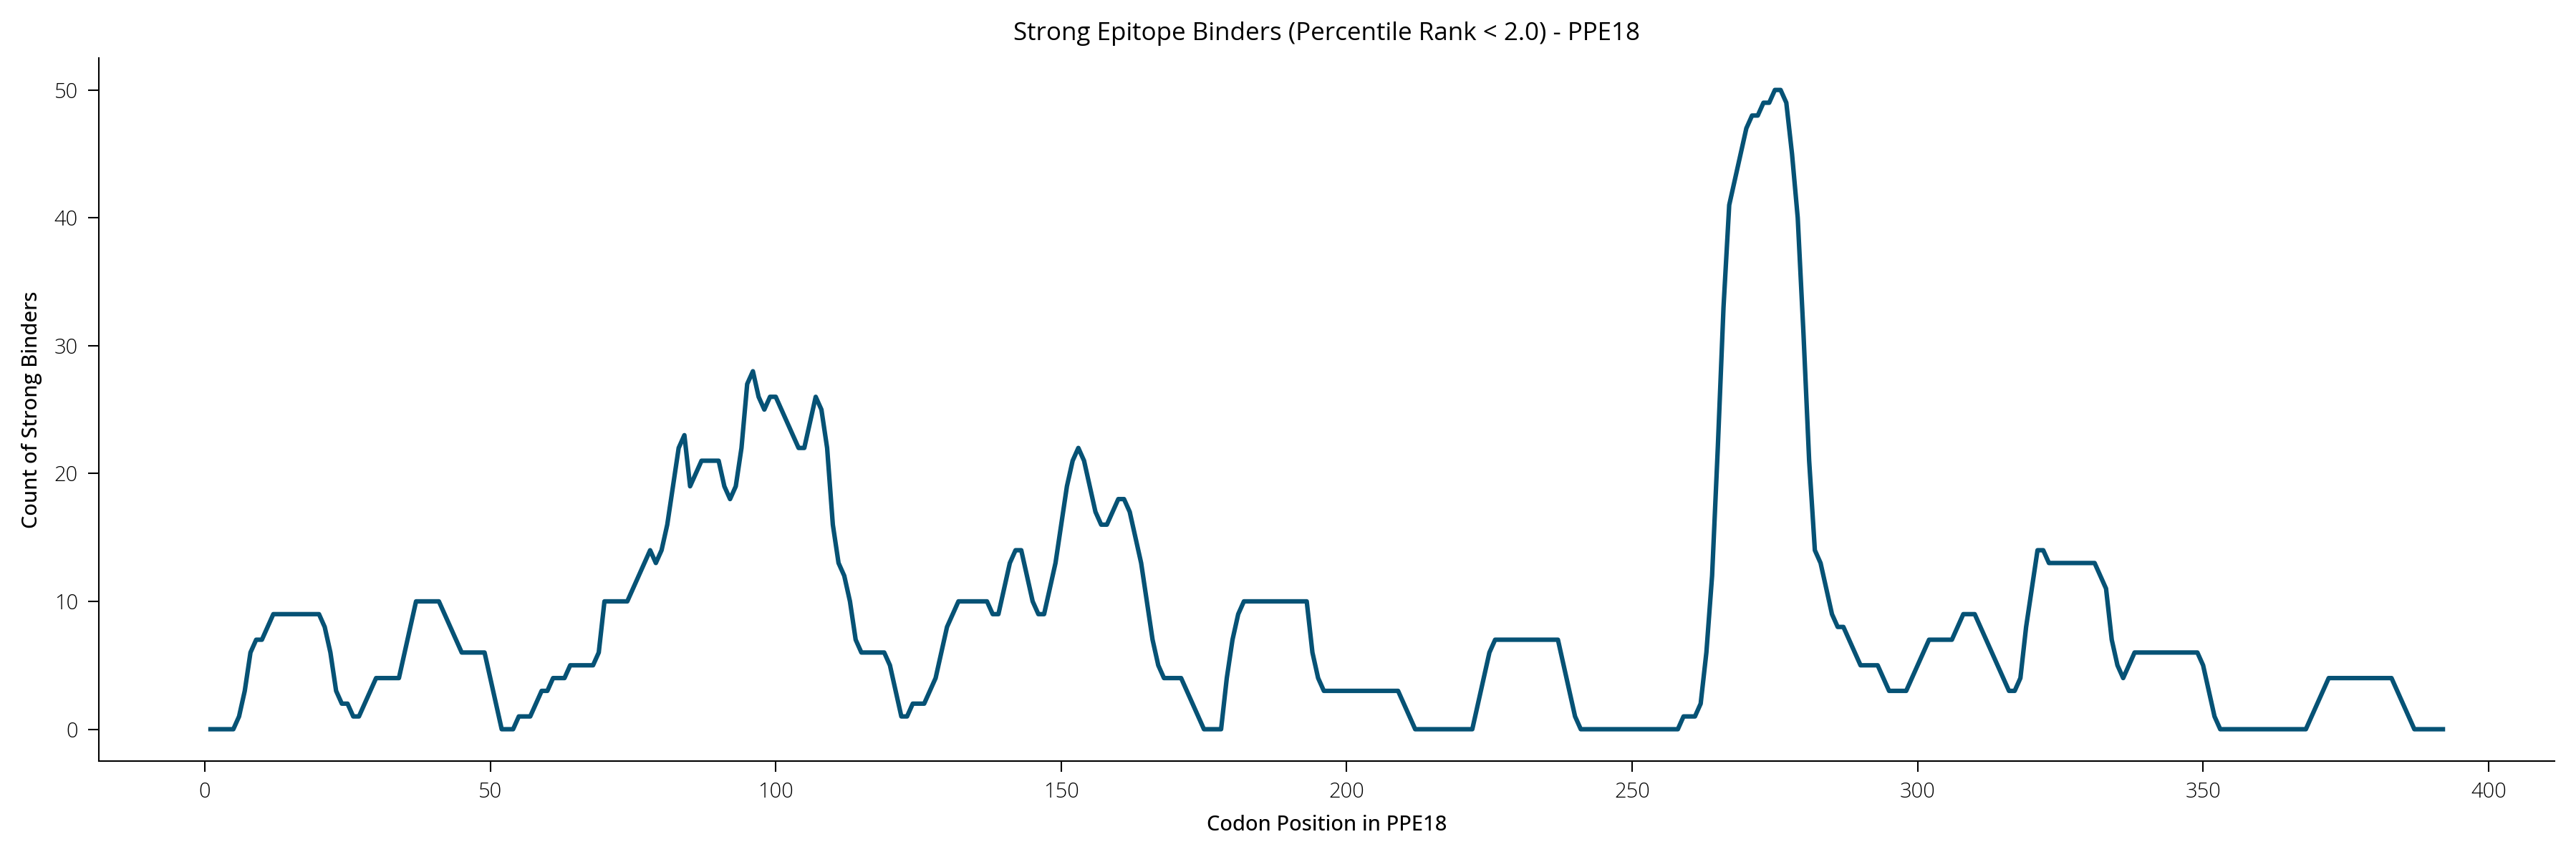

In [1114]:
plt.figure(figsize=(12, 4))
sns.lineplot(data=PPE18_netMHC_SB_Cov_DF,
             x="Codon", y="netMHCpan_Strong_Binder_Ct",
             linewidth=1.5)

plt.title("Strong Epitope Binders (Percentile Rank < 2.0) - PPE18")
plt.xlabel("Codon Position in PPE18")
plt.ylabel("Count of Strong Binders")
plt.tight_layout()
sns.despine()
plt.show()

# Part A: 

In [ ]:

# Function to compute 0-based genomic position for the first nucleotide of each codon (in coding direction)
def codon_to_pos0(start0, end0, codon_idx_1based, strand_sign):
    k = int(codon_idx_1based)
    if strand_sign == "+":
        # first nt of codon k
        return start0 + (k - 1) * 3
    else:
        # first nt (in coding direction) of codon k on minus strand
        return (end0 - 1) - (k - 1) * 3


In [ ]:
antigen_stats = Antigen_GCandMutFreqStats_DF

In [ ]:
per_codon = RvPerCodon_NSMutFreq_DF

In [ ]:
epi_cov = Rv_EpitopeCov_NonZero_DF

In [ ]:
# --- 1) Get PPE18 metadata (coordinates & length) ---
ppe18_row = antigen_stats.query("Symbol == 'PPE18'").copy()
if ppe18_row.empty:
    raise ValueError("Couldn't find PPE18 in the antigen stats table.")
ppe18_row = ppe18_row.iloc[0]

chrom = ppe18_row["Chrom"]
PPE18_start = int(ppe18_row["Start"])
PPE18_end   = int(ppe18_row["End"])
PPE18_strand = ppe18_row["Strand"]
length_DNA = int(ppe18_row["Length"])
length_aa = int(391) #int(length_DNA / 3) #ppe18_AA_length

In [ ]:
length_aa

In [ ]:
ppe18_AA_length

In [ ]:
antigen_stats.query("Symbol == 'PPE18'")

In [ ]:
per_codon.head()

In [ ]:
ppe18_codon_counts.head(3)

In [ ]:
# --- Mutation counts at each codon for PPE18 (also keep any Pos_0based present in the data) ---
ppe18_codon_counts = (
    per_codon
    .query("Symbol == 'PPE18'")
    .assign(Codon=lambda d: d["Codon"].astype(int))
    .groupby(["Codon"], as_index=False)
    .agg(Mutation_Count=("Mutation_Count", "sum"),
         Pos0_from_data=("Pos_0based", "first"))
)

# --- Build "full" codon index and compute Pos_0based for each codon ---
full = pd.DataFrame({"Symbol": ["PPE18"] * length_aa, "Codon": np.arange(1, length_aa + 1, dtype=int)})
full["Pos_0based"] = full["Codon"].apply(lambda k: codon_to_pos0(PPE18_start, PPE18_end, k, PPE18_strand))

# Merge in counts (and the Pos0 observed in per-codon table, for comparison)
full = full.merge(ppe18_codon_counts, on="Codon", how="left")
full["Mutation_Count"] = full["Mutation_Count"].fillna(0).astype(int)


full = full.merge(epi_cov, left_on = "Pos_0based", right_on="start", how="left")


full = full.merge(PPE18_netMHC_SB_Cov_DF, on = "Codon", how="left")


# Reorder
# full = full[["Symbol", "Codon", "Pos_0based",
#              "Mutation_Count",
#              "Cov_PosEpitopes", "Cov_AssayedPeptides", 
#              "netMHCpan_Strong_Binder_Ct"]]

PPE18_full = full

PPE18_full.shape

In [ ]:
PPE18_full.tail()

In [ ]:
PPE18_netMHC_SB_Cov_DF.head()

In [ ]:
PPE18_full.head()

In [ ]:
PPE18_full.sort_values("Mutation_Count", ascending = False).head(5)

In [ ]:
PPE18_full.sort_values("Cov_PosEpitopes", ascending = False).head(5)

In [ ]:
PPE18_full.sort_values(["Mutation_Count", "Cov_PosEpitopes"], ascending = False).head(5)

In [ ]:
epi_cov.head()

# Plot stats

In [ ]:
merged = PPE18_full
merged.shape

In [ ]:
merged.head(2)

In [ ]:
import matplotlib.pyplot as plt

# Example data (replace with your merged PPE18 table)
df = merged.copy()

x = df["Codon"]

# Define which stats you want to plot
stats_to_plot = [
    ("Mutation_Count", "Mutations"),
    ("Cov_PosEpitopes", "Positive Epitope Coverage"),
    ("Cov_AssayedPeptides", "Assayed Peptide Coverage"),
    ("netMHCpan_Strong_Binder_Ct", "# of HLA alleles w/ predicted strong binding (netMHCpanII)"),
]

n_rows = len(stats_to_plot)

fig, axes = plt.subplots(n_rows, 1, figsize=(10, 2.5 * n_rows), sharex=True)

for ax, (col, label) in zip(axes, stats_to_plot):
    ax.plot(x, df[col], lw=1.2)
    ax.set_ylabel(label)
    ax.grid(True, linestyle="--", alpha=0.4)

axes[-1].set_xlabel("Codon position (PPE18)")
fig.suptitle("PPE18 Codon-Level Statistics", y=0.95, fontsize=14)
sns.despine()
plt.tight_layout()
plt.show()


# Try PPE18 correlation analysis

In [ ]:
PPE18_full.head()

In [ ]:
merged = PPE18_full
merged.shape

In [ ]:
merged.head(3)

In [ ]:
merged.tail(2)

## Run code

In [ ]:
import pandas as pd, numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedPoisson, ZeroInflatedNegativeBinomialP
import matplotlib.pyplot as plt

In [ ]:
# ---------- Correlations ----------
x = merged["Cov_PosEpitopes"].to_numpy()
y = merged["Mutation_Count"].to_numpy()
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_rho, spearman_p = stats.spearmanr(x, y)
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.2e}")
print(f"Spearman rho={spearman_rho:.3f}, p={spearman_p:.2e}")

# ---------- Scatter plot ----------
coeff = np.polyfit(x, y, deg=1) if len(merged) > 1 else (0,0)
x_line = np.linspace(x.min(), x.max(), 100) if len(merged) > 1 else np.array([0,1])
y_line = coeff[0]*x_line + coeff[1]

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=12, alpha=0.7)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("Number of experimentally positive epitopes covering codon")
plt.ylabel("Number of missense mutations observed")
plt.title("PPE18: Codon mutations vs epitope coverage")
plt.tight_layout()
plt.show()

### `GLMs`

In [ ]:

# ---------- GLMs ----------
reg_df = merged.copy()
reg_df["Epitope_Cov"] = reg_df["Cov_PosEpitopes"].astype(float)
reg_df["Assayed_Cov"] = reg_df["Cov_AssayedPeptides"].astype(float)
reg_df["Mutations"] = reg_df["Mutation_Count"].astype(int)

# Poisson (simple)
pois_A = smf.glm("Mutations ~ Epitope_Cov", data=reg_df, family=sm.families.Poisson()).fit()
print(pois_A.summary())
print("Overdispersion ratio:", pois_A.pearson_chi2 / pois_A.df_resid)


In [ ]:

# Poisson (offset by assay coverage)
reg_df["offset_log_assayed"] = np.log(reg_df["Assayed_Cov"] + 1.0)
pois_B = smf.glm("Mutations ~ Epitope_Cov", data=reg_df, family=sm.families.Poisson(),
                 offset=reg_df["offset_log_assayed"]).fit()
print(pois_B.summary())
print("Overdispersion ratio (offset):", pois_B.pearson_chi2 / pois_B.df_resid)

In [ ]:

# Negative Binomial (simple)
nb_A = smf.glm("Mutations ~ Epitope_Cov", data=reg_df, family=sm.families.NegativeBinomial()).fit()
print(nb_A.summary())

# Negative Binomial (offset)
nb_B = smf.glm("Mutations ~ Epitope_Cov", data=reg_df, family=sm.families.NegativeBinomial(),
               offset=reg_df["offset_log_assayed"]).fit()
print(nb_B.summary())


In [ ]:

# Zero-inflated (optional sensitivity)
endog = reg_df["Mutations"]
exog  = sm.add_constant(reg_df["Epitope_Cov"])
exog_infl = sm.add_constant(reg_df["Epitope_Cov"])

try:
    zip_model = ZeroInflatedPoisson(endog, exog, exog_infl=exog_infl, inflation='logit').fit(disp=0, maxiter=200)
    print(zip_model.summary())
except Exception as e:
    print("ZIP failed:", e)

try:
    zinb_model = ZeroInflatedNegativeBinomialP(endog, exog, exog_infl=exog_infl, inflation='logit').fit(disp=0, maxiter=200)
    print(zinb_model.summary())
except Exception as e:
    print("ZINB failed:", e)

In [ ]:
merged.head()

In [ ]:
# ---------- Correlations ----------
x = merged["netMHCpan_Strong_Binder_Ct"].to_numpy()
y = merged["Mutation_Count"].to_numpy()
pearson_r, pearson_p = stats.pearsonr(x, y)
spearman_rho, spearman_p = stats.spearmanr(x, y)
print(f"Pearson r={pearson_r:.3f}, p={pearson_p:.2e}")
print(f"Spearman rho={spearman_rho:.3f}, p={spearman_p:.2e}")

# ---------- Scatter plot ----------
coeff = np.polyfit(x, y, deg=1) if len(merged) > 1 else (0,0)
x_line = np.linspace(x.min(), x.max(), 100) if len(merged) > 1 else np.array([0,1])
y_line = coeff[0]*x_line + coeff[1]

plt.figure(figsize=(6,4))
plt.scatter(x, y, s=12, alpha=0.7)
plt.plot(x_line, y_line, linewidth=2)
plt.xlabel("Number of PREDICTED strong binders by netMHCPanII")
plt.ylabel("Number of missense mutations observed")
plt.title("PPE18: Codon mutations vs # of HLA alleles w/ strong binding ")
plt.tight_layout()
plt.show()

In [ ]:

# ---------- GLMs ----------
reg_df = merged.copy()
reg_df["Epitope_Cov"] = reg_df["netMHCpan_Strong_Binder_Ct"].astype(float)
reg_df["Assayed_Cov"] = reg_df["Cov_AssayedPeptides"].astype(float)
reg_df["Mutations"] = reg_df["Mutation_Count"].astype(int)

# Poisson (simple)
pois_A = smf.glm("Mutations ~ Epitope_Cov", data=reg_df, family=sm.families.Poisson()).fit()
print(pois_A.summary())
print("Overdispersion ratio:", pois_A.pearson_chi2 / pois_A.df_resid)


# Extras

# Phase 2 - Part 3:

### Create a Dict that maps each epitope sequence to all gene's that contain the sequence

In [1120]:
# Group by 'Epitope_Seq' and aggregate the unique 'Symbol' values into a string
EpiSeq_to_Symbols_dict = (LPM_AllPep_V2_DF.groupby('Epitope_Seq')['Symbol']
    .apply(lambda x: ', '.join(x.unique()))
    .to_dict()
)    

In [1121]:
EpiSeq_to_Symbols_dict["DLYSKIESLPASQRD"]

'icd2'

### `Lind-16` - parse and process HLA and epitope positivity info in 63 ZA individuals

In [1122]:
Lind16_IEDB_AllPeptides_HLAInfo_DF = pd.read_csv(Lind16_Peptides_HLAInfo_TSV, sep = "\t")

Lind16_IEDB_AllPeptides_HLAInfo_DF["Gene(s)"] = Lind16_IEDB_AllPeptides_HLAInfo_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_IEDB_PosEpitopes_HLAInfo_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.query("Epitope_Status == 'Positive' ")


# Group by "Epitope_Seq" and sum the relevant numeric columns
Lind16_EpiPosFreq_DF = Lind16_IEDB_AllPeptides_HLAInfo_DF.groupby("Epitope_Seq")["Num_Positive"].sum()
Lind16_EpiPosFreq_DF = Lind16_EpiPosFreq_DF.reset_index()

Lind16_EpiPosFreq_DF["Num_Assayed"] = 63

# Assuming Num_Assayed is 63 for each epitope, calculate the fraction of individuals positive for each epitope
Lind16_EpiPosFreq_DF['Fraction_Positive'] = Lind16_EpiPosFreq_DF['Num_Positive'] / 63

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Epitope_Seq"].map(EpiSeq_to_Symbols_dict)

Lind16_EpiPosFreq_DF["Gene(s)"] = Lind16_EpiPosFreq_DF["Gene(s)"].fillna("")


In [1123]:
Lind16_IEDB_AllPeptides_HLAInfo_DF.head(3)

,Epitope_Seq,Epitope_Status,HLA_Allele,Num_Assayed,Num_Positive,Fraction_PositiveAssay,Gene(s)
0,DAHGAMIRAQAGSLE,Positive,HLA-DQB1*06:02,5,5,1.0,"esxI, esxV"
1,ISTNIRQAGVQYSRA,Positive,HLA-DQB1*06:02,4,4,1.0,esxB
2,MHVSFVMAYPEMLAA,Positive,HLA-DQB1*06:02,4,4,1.0,NaN


## A) Pre-process and create Lindestam-2016 DF of Peptide Info

In [1124]:
L16_AllPep_V2_DF = LPM_AllPep_V2_DF.query("Assayed_Lindestam16 == True")
L16_AllPep_V2_DF.shape

(893, 31)

In [1126]:
L16_AllPep_V3_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI
0,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,12,63,0.190476,esxB,0.190476


In [1127]:
L16_AllPep_V3_DF = pd.merge(L16_AllPep_V2_DF, Lind16_EpiPosFreq_DF,
                            on = "Epitope_Seq", how = "inner" )

L16_AllPep_V3_DF["Epitope_ResponseFreq_LTBI"] = L16_AllPep_V3_DF["Fraction_Positive"]

L16_AllPep_V3_DF["IsMutByGCE"] = L16_AllPep_V3_DF["IsMutBypGCE"].astype(str)

L16_AllPep_V3_DF.shape

(893, 37)

In [1128]:
L16_AllPep_V3_InL2Antigen_DF = L16_AllPep_V3_DF.query("Antigen_LVL2 == True")

L16_PosEpi_V3_InL2Antigen_DF = L16_AllPep_V3_InL2Antigen_DF.query("PosEpitope_Lindestam16 == True")



L16_AllPep_V3_InL2Antigen_DF = bf.count_overlaps(L16_AllPep_V3_InL2Antigen_DF,
                                                 L16_PosEpi_V3_InL2Antigen_DF,
                                              cols1 = ["Chrom", "Rv_Start", "Rv_End"],
                                              cols2 = ["Chrom", "Rv_Start", "Rv_End"],)

L16_AllPep_V3_InL2Antigen_DF = L16_AllPep_V3_InL2Antigen_DF.rename(columns={"count": "N_Ovrlap_PosEpi"})
L16_AllPep_V3_InL2Antigen_DF["Ovrlap_PosEpi"] = L16_AllPep_V3_InL2Antigen_DF["N_Ovrlap_PosEpi"] > 0

L16_AllPep_V3_InL2Antigen_DF.shape

(765, 39)

In [1129]:
L16_PosEpi_V3_InL2Antigen_DF = L16_AllPep_V3_InL2Antigen_DF.query("PosEpitope_Lindestam16 == True")
L16_PosEpi_V3_InL2Antigen_DF.shape

(299, 39)

In [1130]:
L16_AllPep_V3_InL2Antigen_DF.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,IsMutByGCE,N_Ovrlap_PosEpi,Ovrlap_PosEpi
0,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,12,63,0.190476,esxB,0.190476,False,7,True


In [1131]:
L16_AllPep_V3_InL2Antigen_DF.to_csv("Lind16.AllPeptidesWithResponseFreq.InHHR.InL2Antigens.tsv", sep="\t", index=False)


In [1132]:
L16_AllPep_V3_InL2Antigen_DF.shape

(765, 39)

In [1133]:
L16_AllPep_V3_InL2Antigen_DF[["PosEpitope_Lindestam16", "Ovrlap_PosEpi"]].value_counts()

PosEpitope_Lindestam16  Ovrlap_PosEpi
True                    True             299
False                   False            278
                        True             188
Name: count, dtype: int64

In [1134]:
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_DF = L16_AllPep_V3_InL2Antigen_DF.query("~(PosEpitope_Lindestam16 == False & Ovrlap_PosEpi == True)")   
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_DF.shape

(577, 39)

In [1135]:
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_DF[["PosEpitope_Lindestam16", "Ovrlap_PosEpi"]].value_counts()

PosEpitope_Lindestam16  Ovrlap_PosEpi
True                    True             299
False                   False            278
Name: count, dtype: int64

In [1137]:
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_InHHR_DF = L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_DF.query("HasHmRegion == True")
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_InHHR_DF.shape

(217, 39)

In [1138]:
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_UNQR_DF = L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_DF.query("HasHmRegion == False")
L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_UNQR_DF.shape

(360, 39)

In [1139]:
L16_PosEpi_V3_DF = L16_AllPep_V3_DF.query("PosEpitope_Lindestam16 == True")
L16_PosEpi_V3_DF.shape

(318, 37)

In [1140]:
L16_PosEpi_InHHR_V3_DF = L16_PosEpi_V3_DF.query("HasHmRegion == True")
L16_PosEpi_InHHR_V3_DF.shape

(158, 37)

In [1141]:
L16_PosEpi_UNQR_V3_DF = L16_PosEpi_V3_DF.query("HasHmRegion == False")
L16_PosEpi_UNQR_V3_DF.shape

(160, 37)

In [1142]:
L16_AllPep_L2Antigens_V3_DF = L16_AllPep_V3_DF.query("Antigen_LVL2 == True")
L16_AllPep_L2Antigens_V3_DF.shape 

(765, 37)

In [1144]:
L16_AllPep_InHHR_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == True")
L16_AllPep_InHHR_V3_DF.shape

(309, 37)

In [1145]:
L16_AllPep_UNQR_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == False")
L16_AllPep_UNQR_V3_DF.shape

(584, 37)

In [1146]:
L16_AllPep_InHHR_L2Antigen_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == True & Antigen_LVL2 == True")
L16_AllPep_InHHR_L2Antigen_V3_DF.shape

(306, 37)

In [1147]:
L16_AllPep_UNQR_L2Antigen_V3_DF = L16_AllPep_V3_DF.query("HasHmRegion == False & Antigen_LVL2 == True")
L16_AllPep_UNQR_L2Antigen_V3_DF.shape

(459, 37)

## B) 

In [1148]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import spearmanr

### Let's evaluate all peptides assayed in Antigens (`L16_AllPep_L2Antigens_V3_DF`)

In [1150]:
L16_AllPep_L2Antigens_V3_DF.head(4)  

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,IsMutByGCE
0,UnqPeptide_29,AQAAVVRFQEAANKQ,15,Rv3874,esxB,50,65,NC_000962.3,4352423,4352468,1,Lindestam16_Panda24_Merged,True,False,True,True,True,UnqPeptide_29-esxB,0,False,True,0,0,False,0,False,0,.,0,.,Positive,12,63,0.190476,esxB,0.190476,False
1,UnqPeptide_48,SGSEAYQGVQQKWDA,15,Rv3875,esxA,45,60,NC_000962.3,4352743,4352788,1,Lindestam16_Panda24_Merged,True,True,True,True,True,UnqPeptide_48-esxA,0,False,True,0,0,False,0,False,0,.,0,.,Positive,2,63,0.031746,esxA,0.031746,False
2,UnqPeptide_51,RHVKPTGSAVVGLSM,15,Rv3804c,fbpA,155,170,NC_000962.3,4266148,4266193,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_51-fbpA,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,fbpA,0.000000,False
3,UnqPeptide_68,GKPANPDVLVVGNGG,15,Rv2608,PPE42,250,265,NC_000962.3,2935795,2935840,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_68-PPE42,0,False,True,0,0,False,0,False,0,.,0,.,Negative,0,63,0.000000,PPE42,0.000000,False


In [1151]:
hhr_df = L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_InHHR_DF.query("Symbol == 'PPE18' ")


In [1152]:
hhr_df.head(1)

,Epitope_ID,Epitope_Seq,Epitope_Len,RvID,Symbol,AA_Start,AA_End,Chrom,Rv_Start,Rv_End,EpitopeSeqFreqInAntigen,Dataset,Assayed_Panda24,PosEpitope_Panda24,Assayed_Lindestam16,PosEpitope_Lindestam16,PosEpitope_Any,EpitopeSymbol_ID,N_HmRegion,HasHmRegion,Antigen_LVL2,N_NSMut_Total,N_NSMut_mGCE,IsMutBymGCE,N_NSMut_pGCE,IsMutBypGCE,N_mGCEs_WiNS,WiNS_mGC_EventIDs,N_pGCEs_WiNS,WiNS_pGC_EventIDs,Reactivity,Num_Positive,Num_Assayed,Fraction_Positive,Gene(s),Epitope_ResponseFreq_LTBI,IsMutByGCE,N_Ovrlap_PosEpi,Ovrlap_PosEpi
13,UnqPeptide_386,LSGVLRVPPRPYVMP,15,Rv1196,PPE18,370,385,NC_000962.3,1340458,1340503,1,Lindestam16_Panda24_Merged,True,False,True,False,False,UnqPeptide_386-PPE18,1,True,True,2,0,False,1,True,0,.,1,Event_098,Negative,0,63,0.0,PPE18,0.0,True,0,False


In [1153]:
hhr_df.shape

(48, 39)

In [1154]:
hhr_df[["Num_Positive", "N_NSMut_Total"]].describe()

,Num_Positive,N_NSMut_Total
count,48.000000,48.000000
mean,1.125000,2.312500
std,1.510601,2.135378
min,0.000000,0.000000
25%,0.000000,0.000000
50%,1.000000,2.000000
75%,2.000000,4.000000
max,7.000000,7.000000


In [1155]:

# Prepare data for HHR peptides
hhr_df = L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_InHHR_DF.query("Symbol == 'PPE18' ")
hhr_df["Y_mutations"] = hhr_df["N_NSMut_Total"]
hhr_df["X_response"] = hhr_df["Num_Positive"]

# Spearman correlation
spearman_rho, spearman_p = spearmanr(hhr_df["Y_mutations"], hhr_df["X_response"])

# Poisson regression
poisson_model = smf.glm("X_response ~ Y_mutations", data=hhr_df, family=sm.families.Poisson()).fit()
poisson_coef = poisson_model.params["Y_mutations"]
poisson_pval = poisson_model.pvalues["Y_mutations"]

# Negative Binomial regression
nb_model = smf.glm("X_response ~ Y_mutations", data=hhr_df, family=sm.families.NegativeBinomial()).fit()
nb_coef = nb_model.params["Y_mutations"]
nb_pval = nb_model.pvalues["Y_mutations"]



# Package results into a dictionary
hhr_stats = {
    "Spearman rho": spearman_rho,
    "Spearman p-value": spearman_p,
    "Poisson Coefficient": poisson_coef,
    "Poisson p-value": poisson_pval,
    "Negative Binomial Coefficient": nb_coef,
    "Negative Binomial p-value": nb_pval
}

hhr_stats


/tmp/ipykernel_2280809/2575623822.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hhr_df["Y_mutations"] = hhr_df["N_NSMut_Total"]
/tmp/ipykernel_2280809/2575623822.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hhr_df["X_response"] = hhr_df["Num_Positive"]
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial disp

{'Spearman rho': 0.24631513616051634,
 'Spearman p-value': 0.09147835748813364,
 'Poisson Coefficient': 0.12501593760363455,
 'Poisson p-value': 0.04022489944095049,
 'Negative Binomial Coefficient': 0.12203253015801167,
 'Negative Binomial p-value': 0.18548238126518157}

/tmp/ipykernel_2280809/1854101531.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hhr_df["Y_mutations"] = hhr_df["N_NSMut_Total"]
/tmp/ipykernel_2280809/1854101531.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hhr_df["X_response"] = hhr_df["Num_Positive"]
/home/mm774/miniforge/envs/bfds_v1/lib/python3.10/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial disp

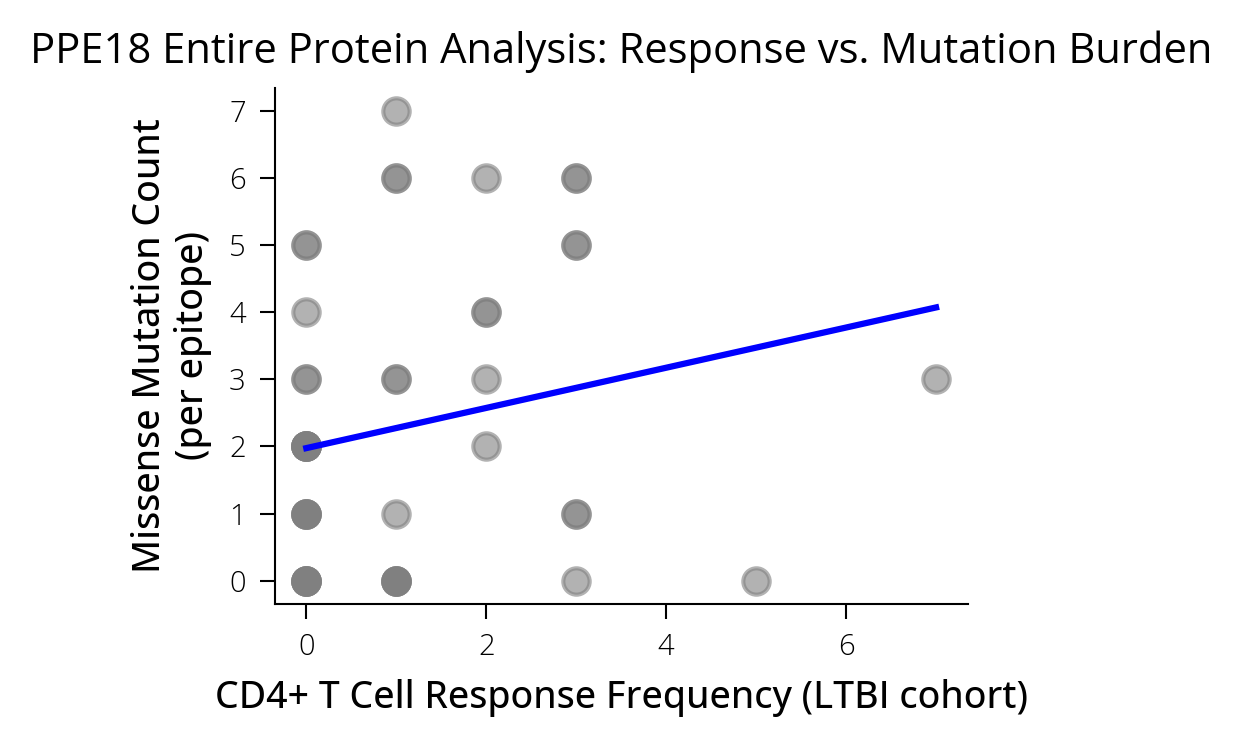

{'Spearman rho': 0.2463151361605163,
 'Spearman p-value': 0.09147835748813367,
 'Poisson Coefficient': 0.11154760848961695,
 'Poisson p-value': 0.0420092949492348,
 'Negative Binomial Coefficient': 0.14061957760891047,
 'Negative Binomial p-value': 0.20544046068907662}

In [1163]:


# Prepare data for HHR peptides
hhr_df = L16_NegPep_Vs_PosEpi_NoOvrlapNegPep_V3_InL2Antigen_InHHR_DF.query("Symbol == 'PPE18' ")
hhr_df["Y_mutations"] = hhr_df["N_NSMut_Total"]
hhr_df["X_response"] = hhr_df["Num_Positive"]

# Spearman correlation
spearman_rho, spearman_p = spearmanr(hhr_df["X_response"], hhr_df["Y_mutations"])

# Poisson regression
poisson_model = smf.glm("Y_mutations ~ X_response", data=hhr_df, family=sm.families.Poisson()).fit()
poisson_coef = poisson_model.params["X_response"]
poisson_pval = poisson_model.pvalues["X_response"]

# Negative Binomial regression
nb_model = smf.glm("Y_mutations ~ X_response", data=hhr_df, family=sm.families.NegativeBinomial()).fit()
nb_coef = nb_model.params["X_response"]
nb_pval = nb_model.pvalues["X_response"]

# Visualization 1: Scatterplot with regression line
plt.figure(figsize=(3, 2.5))
sns.regplot(data=hhr_df,
            x="X_response",
            y="Y_mutations",
            scatter_kws={"alpha": 0.6, "s": 40, "color": "gray"},
            line_kws={"color": "blue"},
            ci=None)
plt.xlabel("CD4+ T Cell Response Frequency (LTBI cohort)", fontsize=9)
plt.ylabel("Missense Mutation Count\n(per epitope)", fontsize=9)
plt.title("PPE18 Entire Protein Analysis: Response vs. Mutation Burden", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()


# Package results into a dictionary
hhr_stats = {
    "Spearman rho": spearman_rho,
    "Spearman p-value": spearman_p,
    "Poisson Coefficient": poisson_coef,
    "Poisson p-value": poisson_pval,
    "Negative Binomial Coefficient": nb_coef,
    "Negative Binomial p-value": nb_pval
}

hhr_stats

/tmp/ipykernel_2280809/3910617714.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hhr_df["Epitope_Status"] = hhr_df["PosEpitope_Lindestam16"].map({True: "Positive Epitope", False: "Negative Peptide"})
/tmp/ipykernel_2280809/3910617714.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=hhr_df,


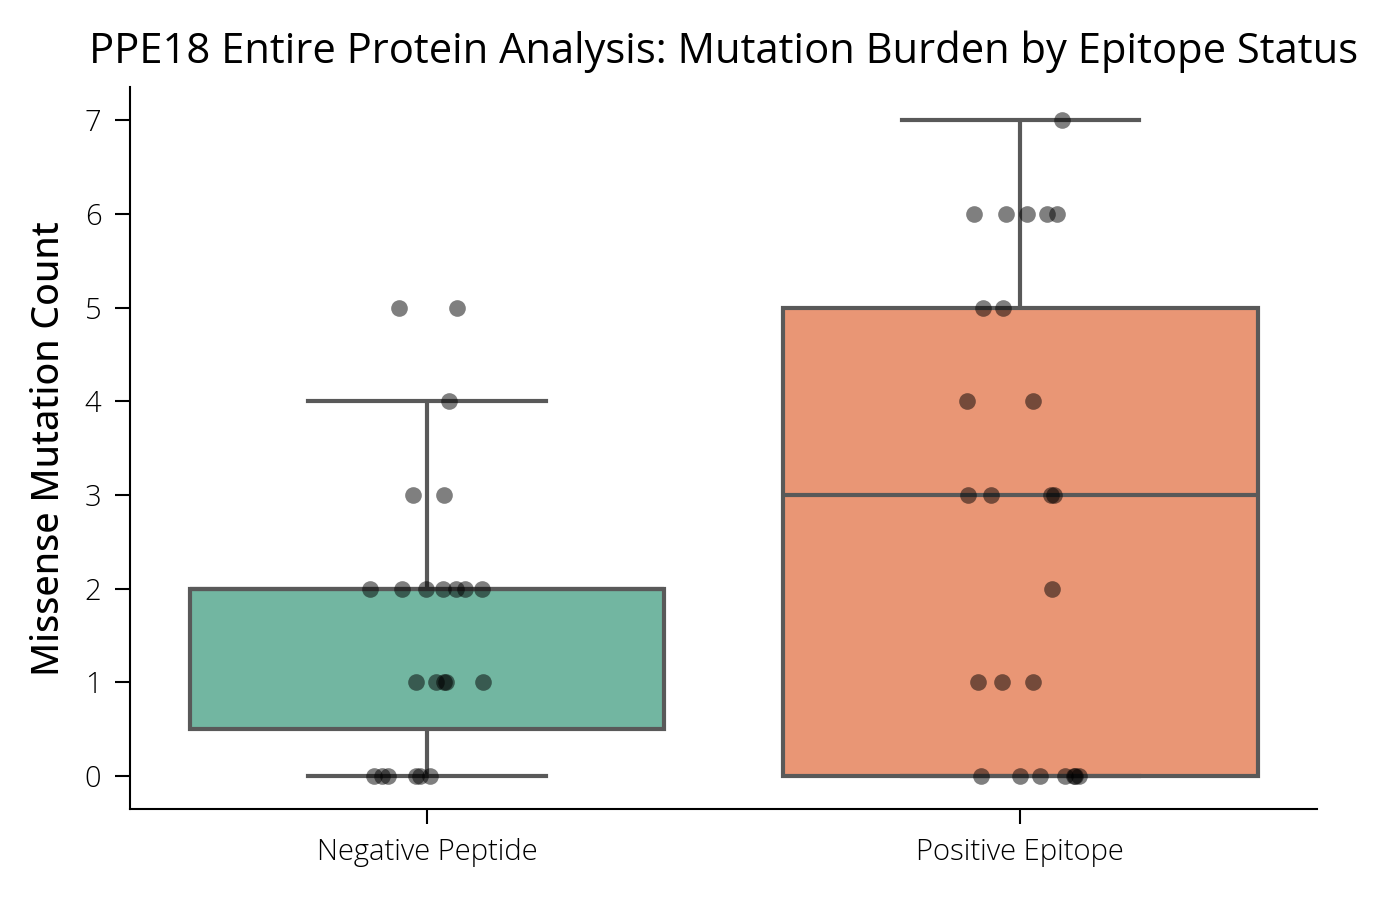

In [1158]:

# Visualization 2: Boxplot grouped by epitope status
hhr_df["Epitope_Status"] = hhr_df["PosEpitope_Lindestam16"].map({True: "Positive Epitope", False: "Negative Peptide"})
plt.figure(figsize=(4.5, 3))
sns.boxplot(data=hhr_df,
            x="Epitope_Status",
            y="Y_mutations", fliersize=0,
            palette="Set2")
sns.stripplot(data=hhr_df,
              x="Epitope_Status",
              y="Y_mutations",
              color="black",
              size=4,
              alpha=0.5)
plt.xlabel("")
plt.ylabel("Missense Mutation Count", fontsize=9)
plt.title("PPE18 Entire Protein Analysis: Mutation Burden by Epitope Status", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()